# **02 — Análisis exploratorio (EDA)**

**Objetivo del proyecto.** Forecasting multi-horizonte (24 h, 72 h, 168 h) de
temperatura del aire `temp_c` sobre un panel nacional de **40 estaciones INMET**
estratificado por las 5 macrorregiones IBGE, cubriendo **2018–2025** (frecuencia
horaria, tz-naive UTC).


## **0. Setup**

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Localización robusta de la raíz del repo (funciona si cwd es notebooks/ o repo/).
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "config").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
# Helpers en src/utils/regions.py usan rutas relativas: alineamos cwd a repo root.
os.chdir(REPO_ROOT)

from src.data.split import split_dataframe
from src.utils import load_yaml, set_seed
from src.utils.regions import all_regions, region_color, region_color_map

cfg = load_yaml(REPO_ROOT / "config" / "config.yaml")
set_seed(cfg["project"]["seed"])

PROCESSED = REPO_ROOT / "data" / "processed"
INTERIM = REPO_ROOT / "data" / "interim"
FIG_DIR = REPO_ROOT / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Estilo consistente de plotting.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 120,
    "savefig.bbox": "tight",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})
REGION_PALETTE = region_color_map()
REGIONS = all_regions()  # orden canónico IBGE


def savefig(fig, name: str) -> Path:
    """Guarda la figura en results/figures/eda/<name>.png a 120 dpi."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    return out


print("REPO_ROOT:", REPO_ROOT)
print("Parquets en data/processed/:", len(sorted(PROCESSED.glob("*.parquet"))))

REPO_ROOT: C:\Users\juana\proyecto-final-deep
Parquets en data/processed/: 40


### **`load_panel()` — panel largo `[datetime × estación]`**

Lee los 40 parquets, hace join con `stations.yaml` (region/biome/koppen) y con
`metadata.json` (lat/lng/alt) y aplica el split temporal — **devuelve sólo
train**. Esto es la barrera explícita anti-leakage de nuestro EDA.

In [2]:
def _parse_metadata_json(path: Path) -> dict:
    """Lee metadata.json (latitude/longitude/altitude) tolerando claves con encoding raro.

    Returns:
        Dict con keys 'latitude', 'longitude', 'altitude' como floats (decimal coma → punto).
    """
    if not path.exists():
        return {"latitude": np.nan, "longitude": np.nan, "altitude": np.nan}
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    out: dict = {}
    for k, v in raw.items():
        ku = k.upper()
        v_str = str(v).replace(",", ".").lstrip(";").strip()
        try:
            v_num = float(v_str)
        except ValueError:
            continue
        if "LATITU" in ku:
            out["latitude"] = v_num
        elif "LONGIT" in ku:
            out["longitude"] = v_num
        elif "ALTIT" in ku:
            out["altitude"] = v_num
    out.setdefault("latitude", np.nan)
    out.setdefault("longitude", np.nan)
    out.setdefault("altitude", np.nan)
    return out


TRAIN_YEARS = set(cfg["split"]["by_year"]["train_years"])


def load_panel(only_train: bool = True) -> pd.DataFrame:
    """Carga el panel completo de 40 estaciones en formato largo.

    Args:
        only_train: Si True, devuelve sólo años en ``cfg.split.by_year.train_years``.
                    Garantía anti-leakage del EDA. Algunas estaciones tienen
                    cobertura parcial (faltan 2024/2025), por eso filtramos por
                    año en lugar de usar ``split_dataframe`` que exigiría splits
                    no vacíos.
    Returns:
        DataFrame con MultiIndex (datetime, wmo) y columnas meteorológicas.
    """
    frames = []
    for path in sorted(PROCESSED.glob("*.parquet")):
        wmo = path.stem
        df = pd.read_parquet(path)
        meta = _parse_metadata_json(INTERIM / wmo / "metadata.json")
        df["wmo"] = wmo
        df["latitude"] = meta["latitude"]
        df["longitude"] = meta["longitude"]
        df["altitude"] = meta["altitude"]
        if only_train:
            df = df[df.index.year.isin(TRAIN_YEARS)]
        if len(df) == 0:
            continue
        frames.append(df)
    panel = pd.concat(frames, axis=0)
    panel.index.name = "datetime"
    panel = panel.set_index("wmo", append=True).reorder_levels(["datetime", "wmo"])
    return panel.sort_index()


PANEL = load_panel(only_train=True)
print("Panel shape:", PANEL.shape)
print("Rango temporal:", PANEL.index.get_level_values('datetime').min(),
      "->", PANEL.index.get_level_values('datetime').max())
print("Estaciones:", PANEL.index.get_level_values('wmo').nunique())

Panel shape: (2098728, 30)
Rango temporal: 2018-01-01 00:00:00 -> 2023-12-31 23:00:00
Estaciones: 40


## **1. Definición y dimensiones del dataset**

In [3]:
n_rows = len(PANEL)
n_stations = PANEL.index.get_level_values("wmo").nunique()
n_cols = PANEL.shape[1]
years = sorted(PANEL.index.get_level_values("datetime").year.unique())
freq_h = pd.infer_freq(PANEL.xs(PANEL.index.get_level_values("wmo")[0], level="wmo").index)

resumen = pd.DataFrame({
    "Métrica": [
        "Estaciones (panel)",
        "Años cubiertos (train)",
        "Frecuencia",
        "Filas totales",
        "Columnas",
        "Filas / estación (promedio)",
    ],
    "Valor": [
        n_stations,
        f"{years[0]}–{years[-1]}",
        freq_h or "h",
        f"{n_rows:,}",
        n_cols,
        f"{n_rows // n_stations:,}",
    ],
})
resumen

,Métrica,Valor
0,Estaciones (panel),40
1,Años cubiertos (train),2018–2023
2,Frecuencia,h
3,Filas totales,"2,098,728"
4,Columnas,30
5,Filas / estación (promedio),"52,468"


In [4]:
# Estaciones por región
by_region = (
    PANEL.reset_index()
    .groupby("region")["wmo"].nunique()
    .reindex(REGIONS)
    .rename("n_estaciones")
    .to_frame()
)
by_region["share_%"] = (by_region["n_estaciones"] / by_region["n_estaciones"].sum() * 100).round(1)
by_region

,n_estaciones,share_%
region,,
Norte,8,20.0
Nordeste,9,22.5
Centro-Oeste,6,15.0
Sudeste,10,25.0
Sul,7,17.5


In [5]:
# Tabla de metadata por estación + cobertura (% no-NaN de temp_c en train)
from src.utils.regions import load_stations

stations_meta = pd.DataFrame(load_stations())[["code", "name", "uf", "region", "biome", "koppen_class"]]
stations_meta = stations_meta.rename(columns={"code": "wmo"}).set_index("wmo")

# Lat/lng/alt por estación
geo = (
    PANEL[["latitude", "longitude", "altitude"]]
    .groupby(level="wmo").first()
)

# Cobertura en train: % filas con temp_c no nulo
cov = (
    PANEL["temp_c"].notna()
    .groupby(level="wmo").mean()
    .mul(100).round(1)
    .rename("cobertura_%")
)

stations_table = stations_meta.join(geo).join(cov).sort_values(["region", "wmo"])
stations_table

,name,uf,region,biome,koppen_class,latitude,longitude,altitude,cobertura_%
wmo,,,,,,,,,
A001,BRASILIA,DF,Centro-Oeste,Cerrado,Aw,-15.789444,-47.925833,1159.54,99.9
A002,GOIANIA,GO,Centro-Oeste,Cerrado,Aw,-16.642778,-49.220000,770.00,99.8
A719,CORUMBA,MS,Centro-Oeste,Pantanal,Aw,-20.475556,-55.783889,155.00,54.5
A756,CAMPO GRANDE,MS,Centro-Oeste,Cerrado,Aw,-20.444444,-52.875556,338.00,96.8
A901,CUIABA,MT,Centro-Oeste,Cerrado,Aw,-15.559167,-56.729444,240.00,94.6
A923,SINOP,MT,Centro-Oeste,Amazonia,Aw,-15.580000,-54.381111,680.00,72.8
A301,SALVADOR - ONDINA,BA,Nordeste,Mata Atlantica,Af,-8.059167,-34.959444,10.00,63.7
A305,BARREIRAS,BA,Nordeste,Cerrado,Aw,-3.832222,-38.537778,26.45,95.2
A309,PETROLINA,PE,Nordeste,Caatinga,BSh,-8.416944,-37.083333,680.70,77.6


### **Decisión de preprocesamiento**
- Mantener el panel **balanceado por región** sólo si `cobertura_% ≥ 90` por estación; las que caigan por debajo se marcarán para exclusión condicional en sección 3.
- `station_id` (entero, ya generado en `process.py`) será la clave para el embedding del modelo global.
- Lat/lng/alt vienen de `metadata.json` y se incorporan como features estáticas por estación (no dinámicas en el tiempo).

### **Impacto en la arquitectura**
- 40 estaciones × ~52 584 horas (train) ⇒ ~2.1 M ejemplos crudos antes de ventaneo. Apto para entrenamiento global con un único modelo + embedding de estación.
- Frecuencia horaria estricta confirmada ⇒ el ventaneo es de paso fijo (sin re-resampling on-the-fly).
- Las 5 regiones tienen 6–10 estaciones cada una: suficiente diversidad climática para que un encoder compartido aprenda representaciones generalizables.



## **2. Análisis de la variable objetivo `temp_c`**

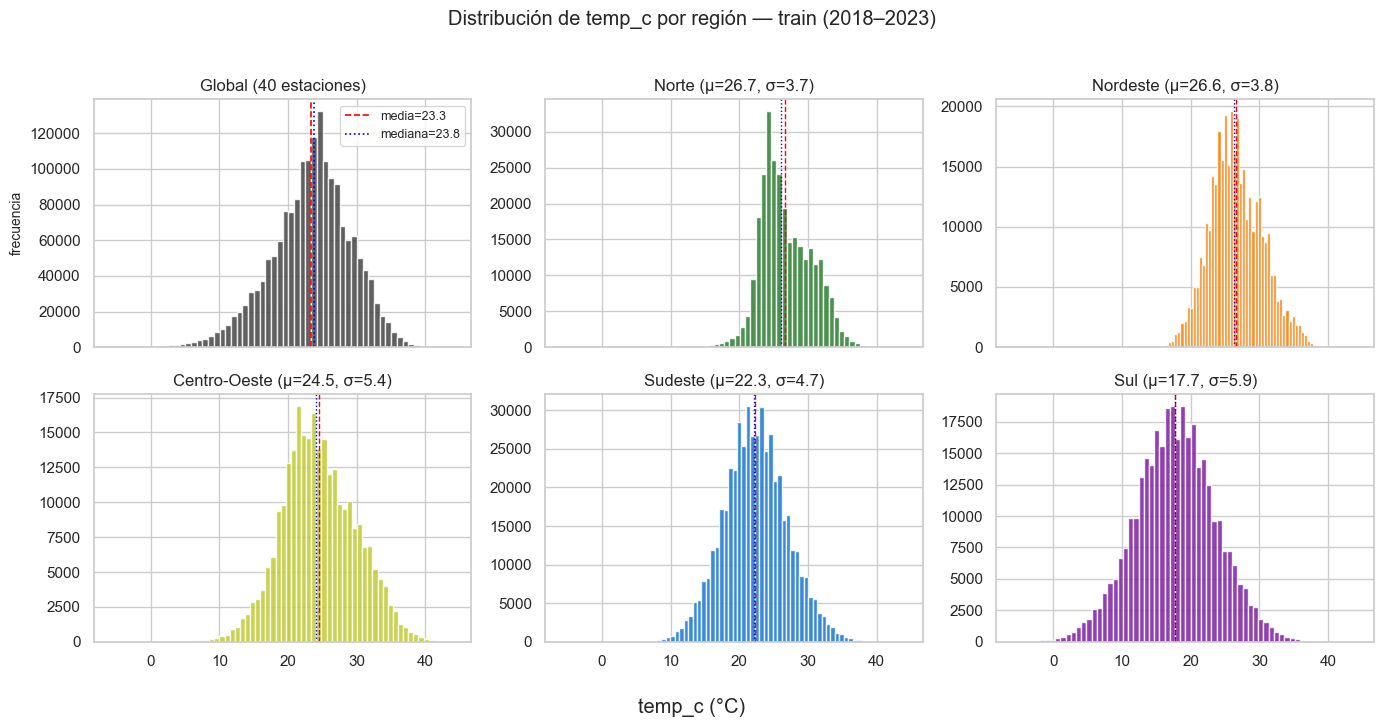

In [6]:
temp = PANEL["temp_c"].dropna()

# Histograma global + por región (5 subplots compartiendo eje X)
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
ax_glob = axes[0, 0]
ax_glob.hist(temp.values, bins=60, color="#444", alpha=0.85)
ax_glob.axvline(temp.mean(), color="red", linestyle="--", lw=1.2, label=f"media={temp.mean():.1f}")
ax_glob.axvline(temp.median(), color="blue", linestyle=":", lw=1.2, label=f"mediana={temp.median():.1f}")
ax_glob.set_title("Global (40 estaciones)")
ax_glob.set_ylabel("frecuencia")
ax_glob.legend()

regions_panel = PANEL.reset_index()
for ax, region in zip(axes.flat[1:], REGIONS):
    s = regions_panel.loc[regions_panel["region"] == region, "temp_c"].dropna()
    ax.hist(s.values, bins=60, color=region_color(region), alpha=0.85)
    ax.axvline(s.mean(), color="red", linestyle="--", lw=1.0)
    ax.axvline(s.median(), color="blue", linestyle=":", lw=1.0)
    ax.set_title(f"{region} (μ={s.mean():.1f}, σ={s.std():.1f})")

fig.suptitle("Distribución de temp_c por región — train (2018–2023)", y=1.02)
fig.supxlabel("temp_c (°C)")
plt.tight_layout()
savefig(fig, "02_target_hist_por_region")
plt.show()

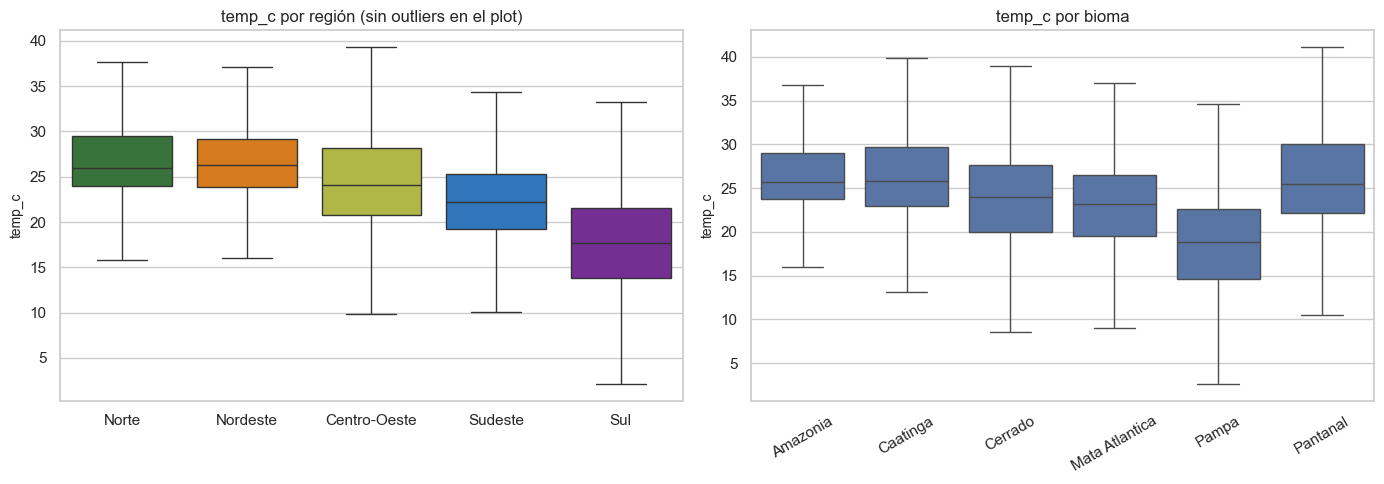

In [7]:
# Boxplot por región y por bioma
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df_box = PANEL.reset_index().dropna(subset=["temp_c"])

sns.boxplot(
    data=df_box, x="region", y="temp_c", order=REGIONS,
    palette=REGION_PALETTE, ax=ax1, showfliers=False,
)
ax1.set_title("temp_c por región (sin outliers en el plot)")
ax1.set_xlabel("")

biomes_order = sorted(df_box["biome"].unique())
sns.boxplot(data=df_box, x="biome", y="temp_c", order=biomes_order, ax=ax2, showfliers=False)
ax2.set_title("temp_c por bioma")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
savefig(fig, "02_target_boxplot_region_bioma")
plt.show()

In [8]:
# Estadísticos descriptivos por región
desc = (
    df_box.groupby("region")["temp_c"]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    .reindex(REGIONS)
    .round(2)
)
desc

,count,mean,std,min,1%,25%,50%,75%,99%,max
region,,,,,,,,,,
Norte,286745.0,26.71,3.73,-5.0,18.5,24.0,26.0,29.5,35.5,40.6
Nordeste,360029.0,26.60,3.83,13.1,18.4,23.9,26.3,29.2,36.0,40.1
Centro-Oeste,272644.0,24.49,5.40,-0.4,12.1,20.8,24.1,28.2,37.0,44.2
Sudeste,503880.0,22.31,4.65,2.8,11.6,19.2,22.2,25.3,33.6,41.7
Sul,342058.0,17.73,5.88,-5.8,3.8,13.8,17.7,21.6,31.4,39.7


In [9]:
# Eventos extremos: percentiles 1 y 99 globales y por región
p_low_global, p_high_global = np.percentile(temp.values, [1, 99])
extremos_region = (
    df_box.groupby("region")["temp_c"]
    .agg(p01=lambda s: np.percentile(s, 1), p99=lambda s: np.percentile(s, 99))
    .reindex(REGIONS)
    .round(2)
)
extremos_region["amplitud_p99-p01"] = (extremos_region["p99"] - extremos_region["p01"]).round(2)
print(f"Global: p01={p_low_global:.2f} °C, p99={p_high_global:.2f} °C")
extremos_region

Global: p01=7.90 °C, p99=35.40 °C


,p01,p99,amplitud_p99-p01
region,,,
Norte,18.5,35.5,17.0
Nordeste,18.4,36.0,17.6
Centro-Oeste,12.1,37.0,24.9
Sudeste,11.6,33.6,22.0
Sul,3.8,31.4,27.6


% horas con temp_c en colas extremas (global): 1.93%


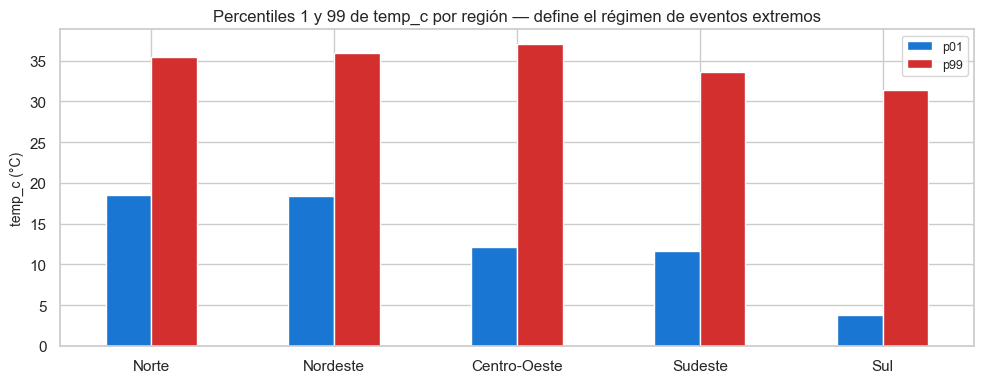

In [10]:
# Visualización de eventos extremos: cuánto del volumen total cae fuera de [p01, p99]
n_extremos = ((temp < p_low_global) | (temp > p_high_global)).sum()
print(f"% horas con temp_c en colas extremas (global): {100*n_extremos/len(temp):.2f}%")

# Por región
fig, ax = plt.subplots(figsize=(10, 4))
extremos_region[["p01", "p99"]].plot(kind="bar", ax=ax,
                                     color=["#1976D2", "#D32F2F"])
ax.set_title("Percentiles 1 y 99 de temp_c por región — define el régimen de eventos extremos")
ax.set_ylabel("temp_c (°C)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
savefig(fig, "02_extremos_p01_p99")
plt.show()

### **Decisión de preprocesamiento**
- **No se balancea artificialmente** la distribución del target: en regresión la cola es información, no ruido. En lugar de eso se incorpora una **columna `is_extreme`** (flag para `temp_c < p01` o `> p99`) calculada **sobre estadísticos de train** y reutilizada en val/test.
- Estandarización **por estación** (no global) en sección de scaling — los rangos varían 30 °C entre regiones (ej. Norte ~22–32, Sul ~5–35).
- Conservar las muestras extremas **sin clipping**; los rangos físicos ya cortan valores imposibles (-10/50 °C).

### **Impacto en la arquitectura**
- En forecasting de regresión no hay "desbalance categórico". Sí hay **desbalance de eventos extremos**: el modelo tenderá a sub-predecir colas si la loss es MSE puro.
- **Loss recomendada**: `Huber` (robusta a outliers) o `quantile loss multi-percentil` (predice p10/p50/p90 simultáneo) para capturar incertidumbre en las colas.
- Embedding por `station_id` permite al modelo aprender el nivel base por estación; las features cíclicas capturan la estacionalidad común.



## **3. Calidad del dataset**

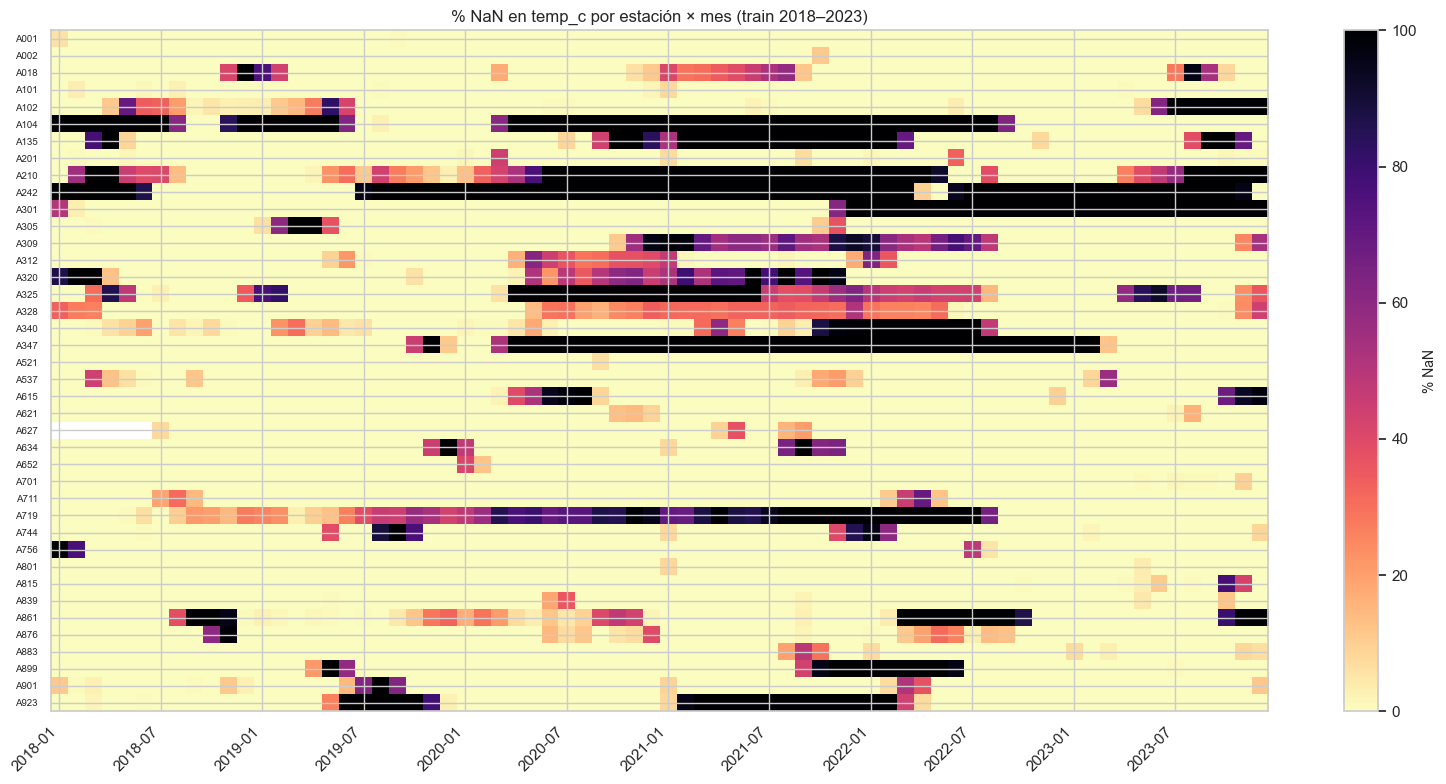

In [11]:
# Heatmap de % NaN en temp_c por (estación × mes-año)
panel_temp = PANEL["temp_c"].copy()
nan_panel = (
    panel_temp.isna()
    .groupby([
        pd.Grouper(level="datetime", freq="MS"),
        pd.Grouper(level="wmo"),
    ])
    .mean()
    .unstack(level="wmo")
    .mul(100)
)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(nan_panel.T.values, aspect="auto", cmap="magma_r", vmin=0, vmax=100)
ax.set_yticks(range(nan_panel.shape[1]))
ax.set_yticklabels(nan_panel.columns, fontsize=7)
xt = np.arange(0, nan_panel.shape[0], 6)
ax.set_xticks(xt)
ax.set_xticklabels([nan_panel.index[i].strftime("%Y-%m") for i in xt], rotation=45, ha="right")
ax.set_title("% NaN en temp_c por estación × mes (train 2018–2023)")
plt.colorbar(im, ax=ax, label="% NaN")
plt.tight_layout()
savefig(fig, "03_heatmap_nan_temp_c")
plt.show()

In [12]:
# Tabla: % faltantes por columna (numéricas) y top 10 estaciones con más NaN en temp_c
num_cols = PANEL.select_dtypes(include="number").columns
nan_por_col = (PANEL[num_cols].isna().mean() * 100).round(2).sort_values(ascending=False)
print("% NaN por columna (todas las estaciones agregadas):")
print(nan_por_col.head(15).to_string())

% NaN por columna (todas las estaciones agregadas):
radiation_kj_m2     31.40
precip_mm           20.22
wind_dir_deg        18.40
dew_point_min_c     17.93
dew_point_max_c     17.92
humidity_max_pct    17.91
humidity_min_pct    17.91
wind_gust_ms        17.85
dew_point_c         17.81
humidity_pct        17.80
wind_speed_ms       17.76
temp_min_c          15.96
temp_max_c          15.96
pressure_max_mb     15.94
pressure_min_mb     15.94


In [13]:
top_nan_station = (
    PANEL["temp_c"].isna().groupby(level="wmo").mean().mul(100).round(2).sort_values(ascending=False).head(10)
).rename("nan_temp_c_%").to_frame()
top_nan_station = top_nan_station.join(stations_meta[["region", "name"]])
top_nan_station

,nan_temp_c_%,region,name
wmo,,,
A242,78.89,Norte,BOA VISTA
A104,62.91,Norte,TEFE
A210,53.99,Norte,MACAPA
A347,51.64,Nordeste,NATAL
A719,45.51,Centro-Oeste,CORUMBA
A325,40.40,Nordeste,SAO LUIS
A301,36.32,Nordeste,SALVADOR - ONDINA
A135,31.31,Norte,PORTO VELHO
A923,27.22,Centro-Oeste,SINOP


In [14]:
# Duplicados temporales: ¿hay (datetime, wmo) repetidos? Ya garantizado por process.py, pero verifica.
dup_count = PANEL.index.duplicated().sum()
print(f"Filas con (datetime, wmo) duplicado: {dup_count}")

# Valores físicamente imposibles que pasaron el clean
out_of_range = (
    (PANEL["temp_c"].dropna() > 50) | (PANEL["temp_c"].dropna() < -20)
).sum()
print(f"Valores temp_c > 50 ó < -20 °C en train: {out_of_range}")

# Otras señales: humedad fuera [0,100], presión fuera [800,1100]
print(f"humidity_pct fuera [0,100]: { ((PANEL['humidity_pct'].dropna() < 0) | (PANEL['humidity_pct'].dropna() > 100)).sum() }")
print(f"pressure_mb fuera [800,1100]: { ((PANEL['pressure_mb'].dropna() < 800) | (PANEL['pressure_mb'].dropna() > 1100)).sum() }")

Filas con (datetime, wmo) duplicado: 0
Valores temp_c > 50 ó < -20 °C en train: 0
humidity_pct fuera [0,100]: 0
pressure_mb fuera [800,1100]: 0


In [15]:
# Gaps largos (> 24 h consecutivas sin temp_c) por estación
def long_gaps_per_station(s: pd.Series, threshold_h: int = 24) -> int:
    is_nan = s.isna().to_numpy()
    if not is_nan.any():
        return 0
    edges = np.diff(np.concatenate([[0], is_nan.astype(int), [0]]))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return int(((ends - starts) > threshold_h).sum())


gap_summary = (
    PANEL["temp_c"].groupby(level="wmo")
    .apply(lambda s: long_gaps_per_station(s.droplevel("wmo"), 24))
    .rename("gaps_>24h")
    .to_frame()
    .join(stations_meta[["region", "name"]])
    .sort_values("gaps_>24h", ascending=False)
)
gap_summary.head(15)

,gaps_>24h,region,name
wmo,,,
A309,77,Nordeste,PETROLINA
A719,39,Centro-Oeste,CORUMBA
A325,33,Nordeste,SAO LUIS
A210,27,Norte,MACAPA
A320,20,Nordeste,MACEIO
A861,19,Sul,FLORIANOPOLIS
A018,16,Norte,PALMAS
A340,16,Nordeste,FORTALEZA
A876,15,Sul,CURITIBA


In [16]:
# Tabla resumen: estaciones candidatas a exclusión si cobertura < 90%
_cov_join = cov.to_frame().join(stations_meta[["region", "name"]])
candidatas_excluir = _cov_join[_cov_join["cobertura_%"] < 90].sort_values("cobertura_%")
print(f"Estaciones con cobertura < 90 %: {len(candidatas_excluir)}")
candidatas_excluir

Estaciones con cobertura < 90 %: 17


,cobertura_%,region,name
wmo,,,
A242,21.1,Norte,BOA VISTA
A104,37.1,Norte,TEFE
A210,46.0,Norte,MACAPA
A347,48.4,Nordeste,NATAL
A719,54.5,Centro-Oeste,CORUMBA
A325,59.6,Nordeste,SAO LUIS
A301,63.7,Nordeste,SALVADOR - ONDINA
A135,68.7,Norte,PORTO VELHO
A923,72.8,Centro-Oeste,SINOP


### **Decisión de preprocesamiento**
- **Mantener todas las estaciones con cobertura ≥ 90 %**; las que estén por debajo se marcan en una lista negra exportable a `config/exclude_stations.yaml` y se decide caso a caso.
- Los **gaps > 24 h** ya quedaron sin imputar tras `process.py` (ffill limit=6). Para entrenamiento, las ventanas que contengan NaN en `temp_c` se descartan en `make_windows` (ya implementado).
- No hay duplicados temporales (`process.py` los deduplica con `keep="first"`); confirmado en celda anterior.

### **Impacto en la arquitectura**
- Estaciones con muchos gaps largos producen menos ventanas de entrenamiento válidas. Para mantener el panel balanceado, se considerará **muestreo proporcional inverso** (estaciones con menos ventanas válidas reciben mayor peso por época) **sólo si la inspección por región muestra desbalance dañino** (sección 4).
- La presencia de NaN residual implica que el `Dataset` de PyTorch debe filtrar ventanas inválidas — no rellenar con `0` (falsearía la señal) ni con la media (introduciría sesgo a la moda climática).



## **4. Identificación de sesgos**

In [17]:
# Sesgo de representación: horas válidas por región
horas_validas = (
    PANEL["temp_c"].notna()
    .groupby(PANEL.reset_index().set_index(PANEL.index)["region"])
    .sum()
    .reindex(REGIONS)
)
n_estaciones = by_region["n_estaciones"]
balance = pd.DataFrame({
    "n_estaciones": n_estaciones,
    "horas_validas": horas_validas.values,
    "horas_validas_por_estacion": (horas_validas.values / n_estaciones.values).astype(int),
})
balance["share_horas_%"] = (balance["horas_validas"] / balance["horas_validas"].sum() * 100).round(1)
balance

,n_estaciones,horas_validas,horas_validas_por_estacion,share_horas_%
region,,,,
Norte,8,286745,35843,16.2
Nordeste,9,360029,40003,20.4
Centro-Oeste,6,272644,45440,15.4
Sudeste,10,503880,50388,28.5
Sul,7,342058,48865,19.4


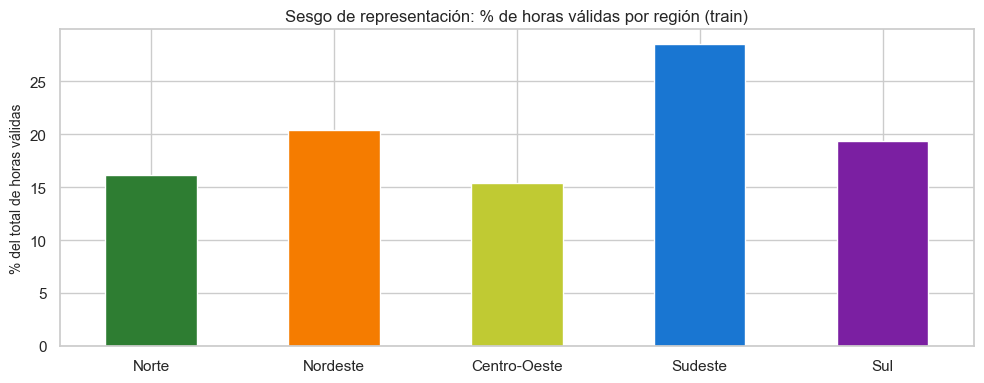

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
balance["share_horas_%"].plot(kind="bar", ax=ax,
                              color=[region_color(r) for r in balance.index])
ax.set_title("Sesgo de representación: % de horas válidas por región (train)")
ax.set_ylabel("% del total de horas válidas")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
savefig(fig, "04_sesgo_representacion")
plt.show()

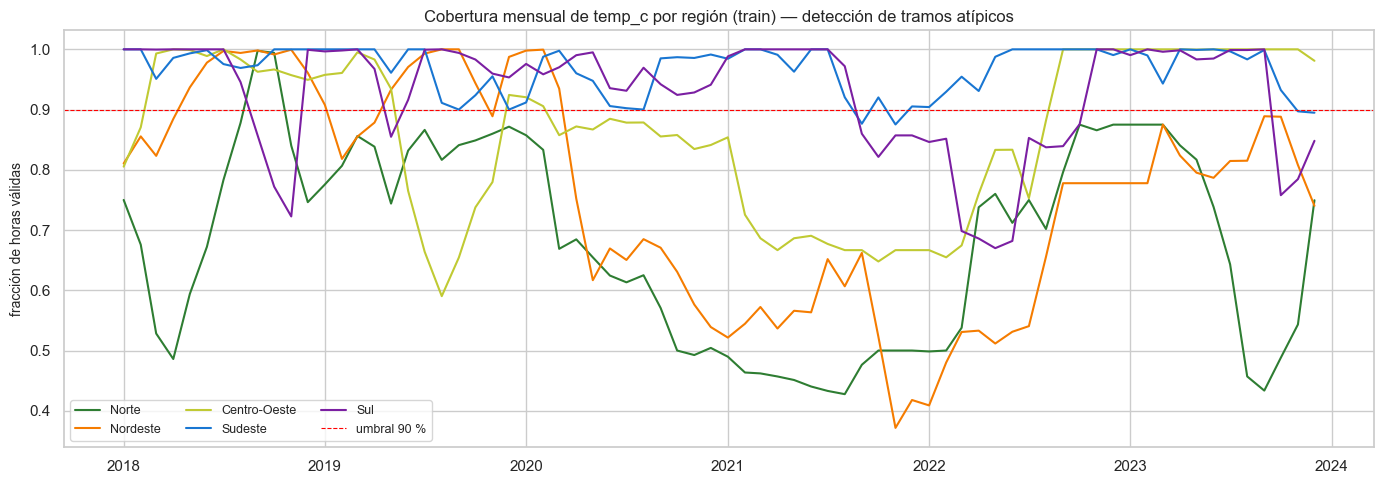

In [19]:
# Sesgo temporal: tramos donde una región completa no reporta
panel_reg = PANEL.reset_index()
mensual = (
    panel_reg.assign(month=panel_reg["datetime"].dt.to_period("M"))
    .groupby(["month", "region"])["temp_c"].apply(lambda s: s.notna().mean())
    .unstack("region")
    .reindex(columns=REGIONS)
)
mensual.index = mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for region in REGIONS:
    ax.plot(mensual.index, mensual[region], color=region_color(region), label=region, lw=1.5)
ax.axhline(0.9, color="red", linestyle="--", lw=0.8, label="umbral 90 %")
ax.set_title("Cobertura mensual de temp_c por región (train) — detección de tramos atípicos")
ax.set_ylabel("fracción de horas válidas")
ax.legend(loc="lower left", ncol=3)
plt.tight_layout()
savefig(fig, "04_sesgo_temporal_region")
plt.show()

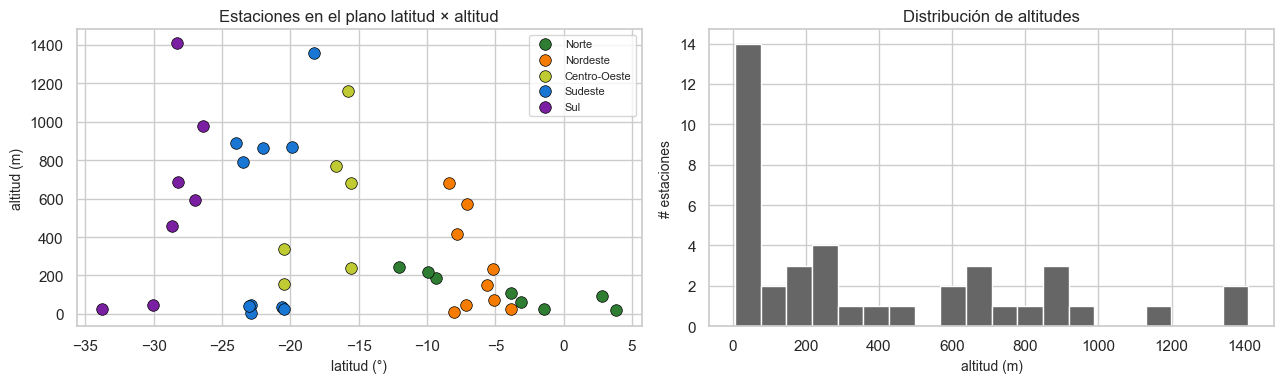

In [20]:
# Sesgo geográfico: histograma de altitudes y latitudes de las 40 estaciones
geo_one = stations_table[["region", "latitude", "longitude", "altitude"]].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for region in REGIONS:
    sub = geo_one[geo_one["region"] == region]
    ax1.scatter(sub["latitude"], sub["altitude"], color=region_color(region),
                label=region, s=70, edgecolor="black", linewidth=0.5)
ax1.set_xlabel("latitud (°)")
ax1.set_ylabel("altitud (m)")
ax1.set_title("Estaciones en el plano latitud × altitud")
ax1.legend(fontsize=8)

ax2.hist(geo_one["altitude"], bins=20, color="#666")
ax2.set_xlabel("altitud (m)")
ax2.set_ylabel("# estaciones")
ax2.set_title("Distribución de altitudes")

plt.tight_layout()
savefig(fig, "04_sesgo_geografico")
plt.show()

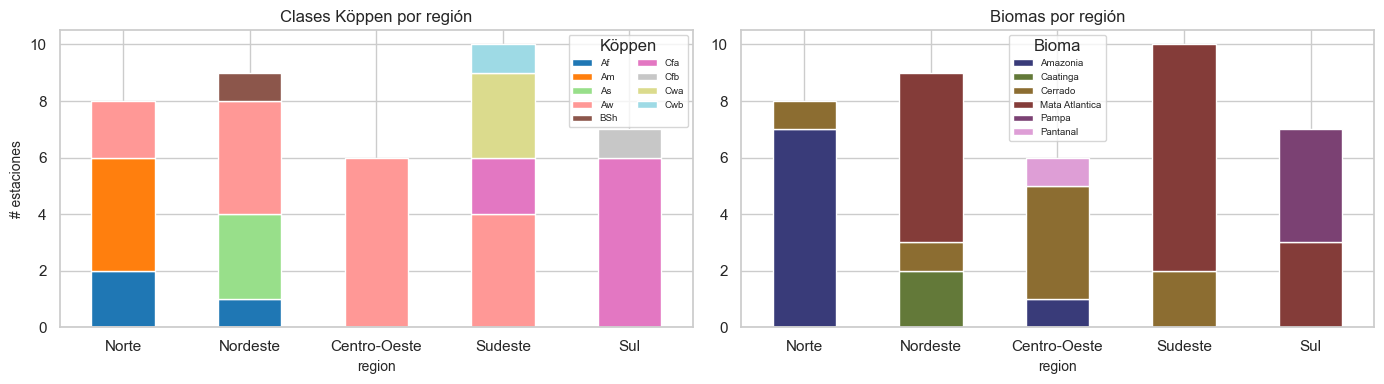

In [21]:
# Sesgo climático: distribución Köppen × bioma × región
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

stations_meta_full = stations_table.copy()
koppen_counts = stations_meta_full.groupby(["region", "koppen_class"]).size().unstack(fill_value=0).reindex(REGIONS)
biome_counts = stations_meta_full.groupby(["region", "biome"]).size().unstack(fill_value=0).reindex(REGIONS)

koppen_counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("Clases Köppen por región")
axes[0].set_ylabel("# estaciones")
axes[0].legend(title="Köppen", fontsize=7, ncol=2)
axes[0].tick_params(axis="x", rotation=0)

biome_counts.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20b")
axes[1].set_title("Biomas por región")
axes[1].legend(title="Bioma", fontsize=7)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
savefig(fig, "04_sesgo_climatico")
plt.show()

### **Decisión de preprocesamiento**
- El panel **no es uniforme**: Sudeste y Nordeste aportan más estaciones (10 y 9) que Norte/Centro-Oeste (8 y 6) y Sul (7) → las regiones con menos estaciones generan menos ejemplos.
- En el **DataLoader**, usar **`WeightedRandomSampler`** con peso `1 / n_horas_validas_por_region` para muestreo balanceado por región durante entrenamiento.
- Las features estáticas `region`, `biome`, `koppen_class` se convierten en **embeddings categóricos**; la cardinalidad pequeña (5 / 7 / 9) las hace baratas y muy informativas.

### **Impacto en la arquitectura**
- **Embedding de región (`dim=4`)**, embedding de bioma (`dim=4`), embedding de Köppen (`dim=4`) — concatenados a las features dinámicas.
- Lat/long/alt entran como features estáticas estandarizadas (no embedding) — la geografía continua aporta información ordinal.
- Si una región queda subrepresentada en eventos extremos, el modelo global no aprenderá bien sus colas → conviene reportar **métricas por región** además de la global en el benchmark.



## **5. Análisis temporal**

Seleccionamos de **una estación representativa por región** para visualizaciones,
descomposición STL, ADF, ACF/PACF y FFT:

In [22]:
# 1 estación representativa por región (priorizando coverage alto)
def representative_per_region() -> dict[str, str]:
    out: dict[str, str] = {}
    for region in REGIONS:
        candidatas = stations_table[stations_table["region"] == region].sort_values("cobertura_%", ascending=False)
        out[region] = candidatas.index[0]
    return out


REPS = representative_per_region()
REPS

{'Norte': 'A101',
 'Nordeste': 'A305',
 'Centro-Oeste': 'A001',
 'Sudeste': 'A521',
 'Sul': 'A801'}

### **5.1 Visualización de la serie**

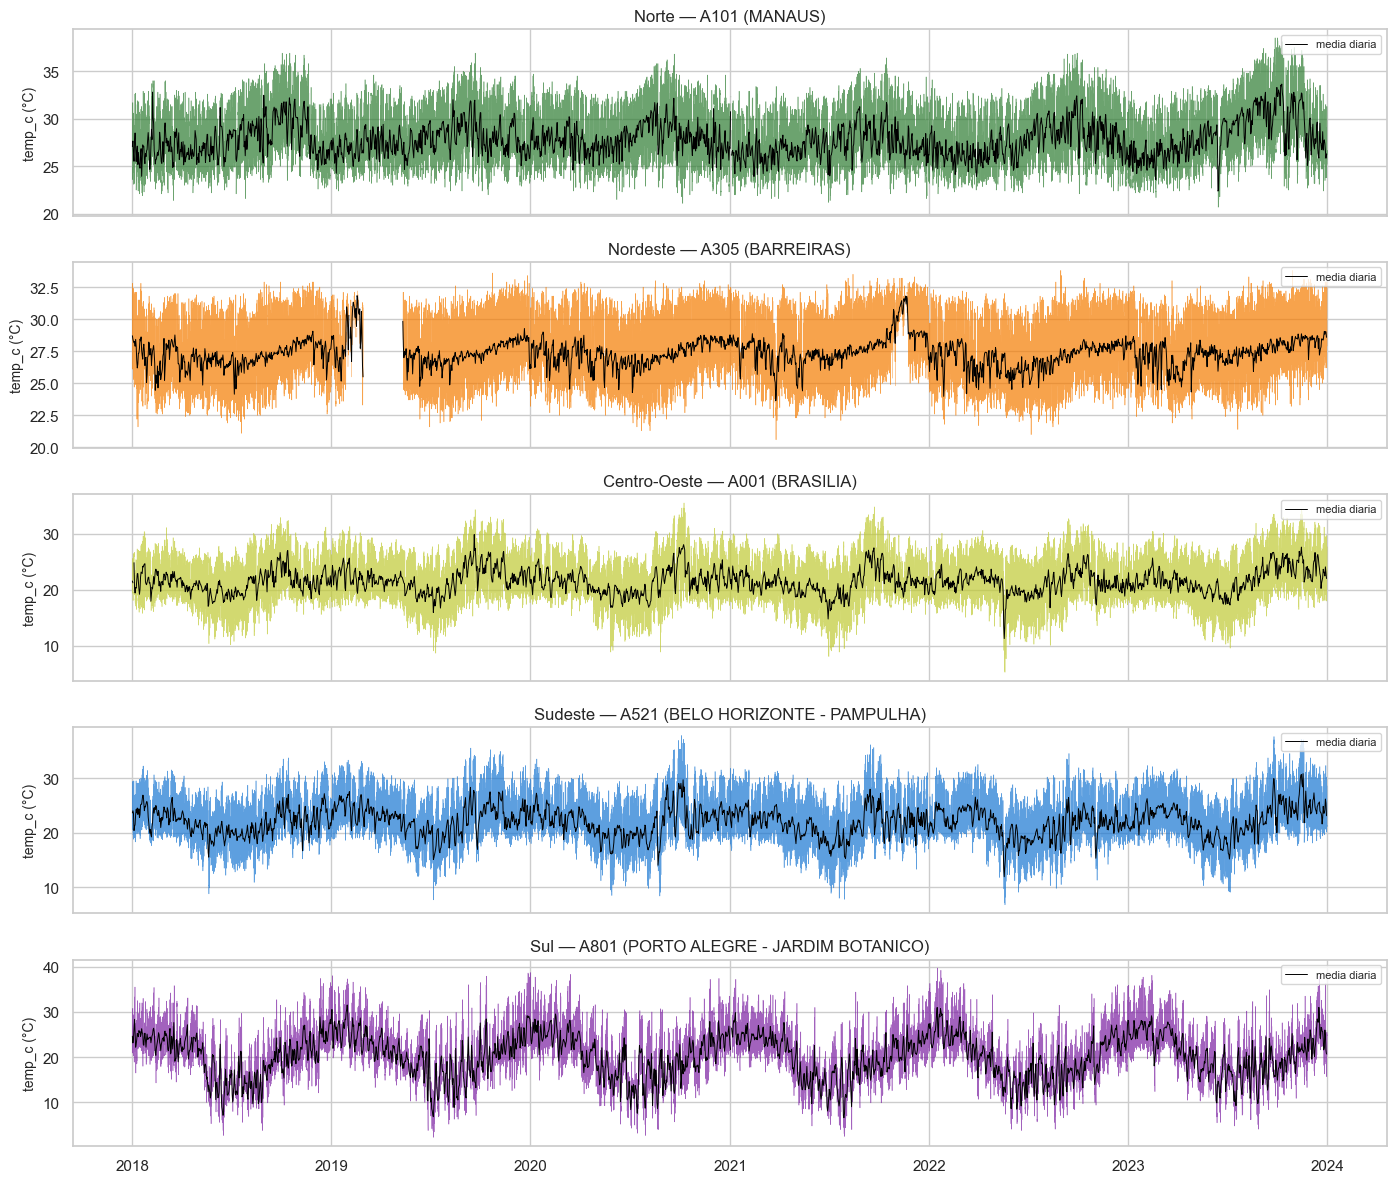

In [23]:
def serie_estacion(wmo: str) -> pd.Series:
    return PANEL.xs(wmo, level="wmo")["temp_c"]


fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, (region, wmo) in zip(axes, REPS.items()):
    s = serie_estacion(wmo)
    ax.plot(s.index, s.values, color=region_color(region), lw=0.4, alpha=0.7)
    daily = s.resample("D").mean()
    ax.plot(daily.index, daily.values, color="black", lw=0.7, label="media diaria")
    ax.set_title(f"{region} — {wmo} ({stations_meta.loc[wmo, 'name']})")
    ax.set_ylabel("temp_c (°C)")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
savefig(fig, "05_1_series_8anos_5reps")
plt.show()

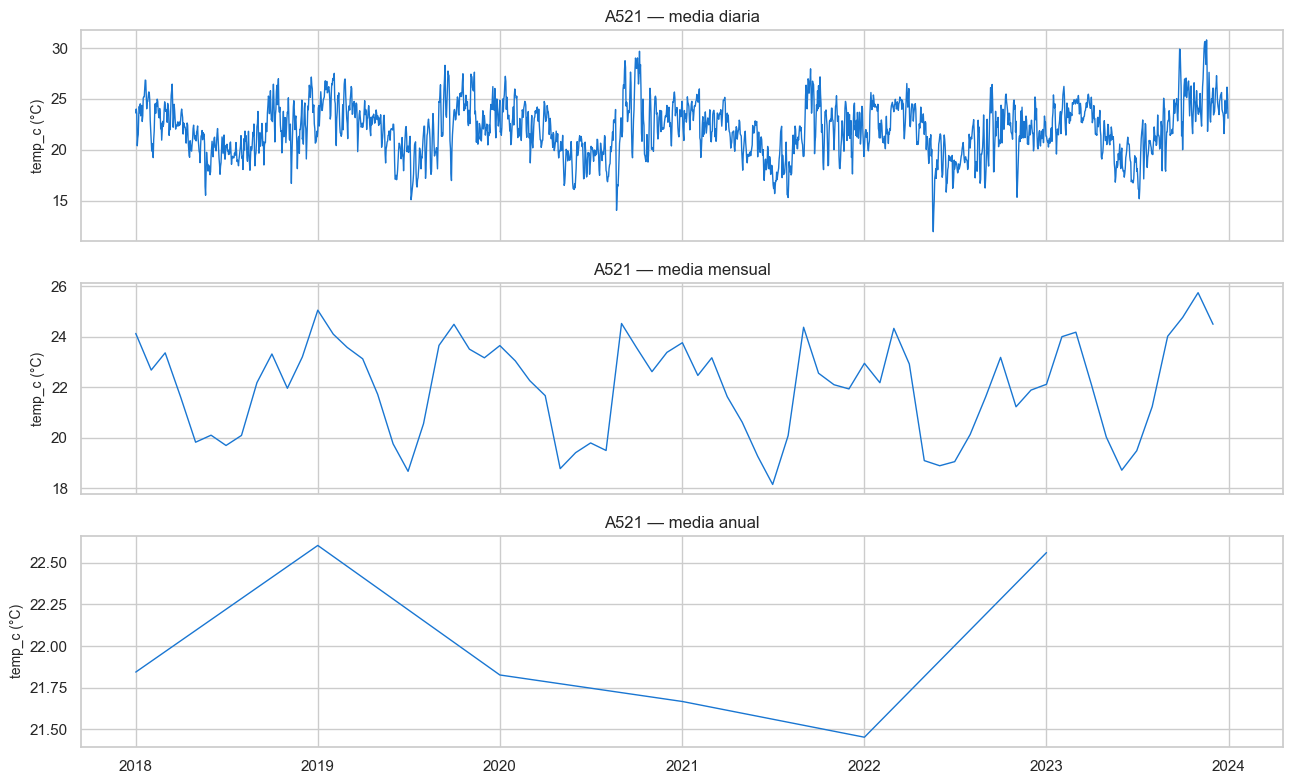

In [24]:
# Resampleo a media diaria, mensual y anual sobre la representativa de Sudeste (A701)
wmo = REPS["Sudeste"]
s = serie_estacion(wmo).dropna()
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, freq, label in zip(axes, ["D", "MS", "YS"], ["diaria", "mensual", "anual"]):
    res = s.resample(freq).mean()
    ax.plot(res.index, res.values, color=region_color("Sudeste"), lw=1.0)
    ax.set_title(f"{wmo} — media {label}")
    ax.set_ylabel("temp_c (°C)")
plt.tight_layout()
savefig(fig, "05_1_resampleo_diaria_mensual_anual")
plt.show()

### **5.2 Descomposición STL (sobre serie diaria, period=365)**

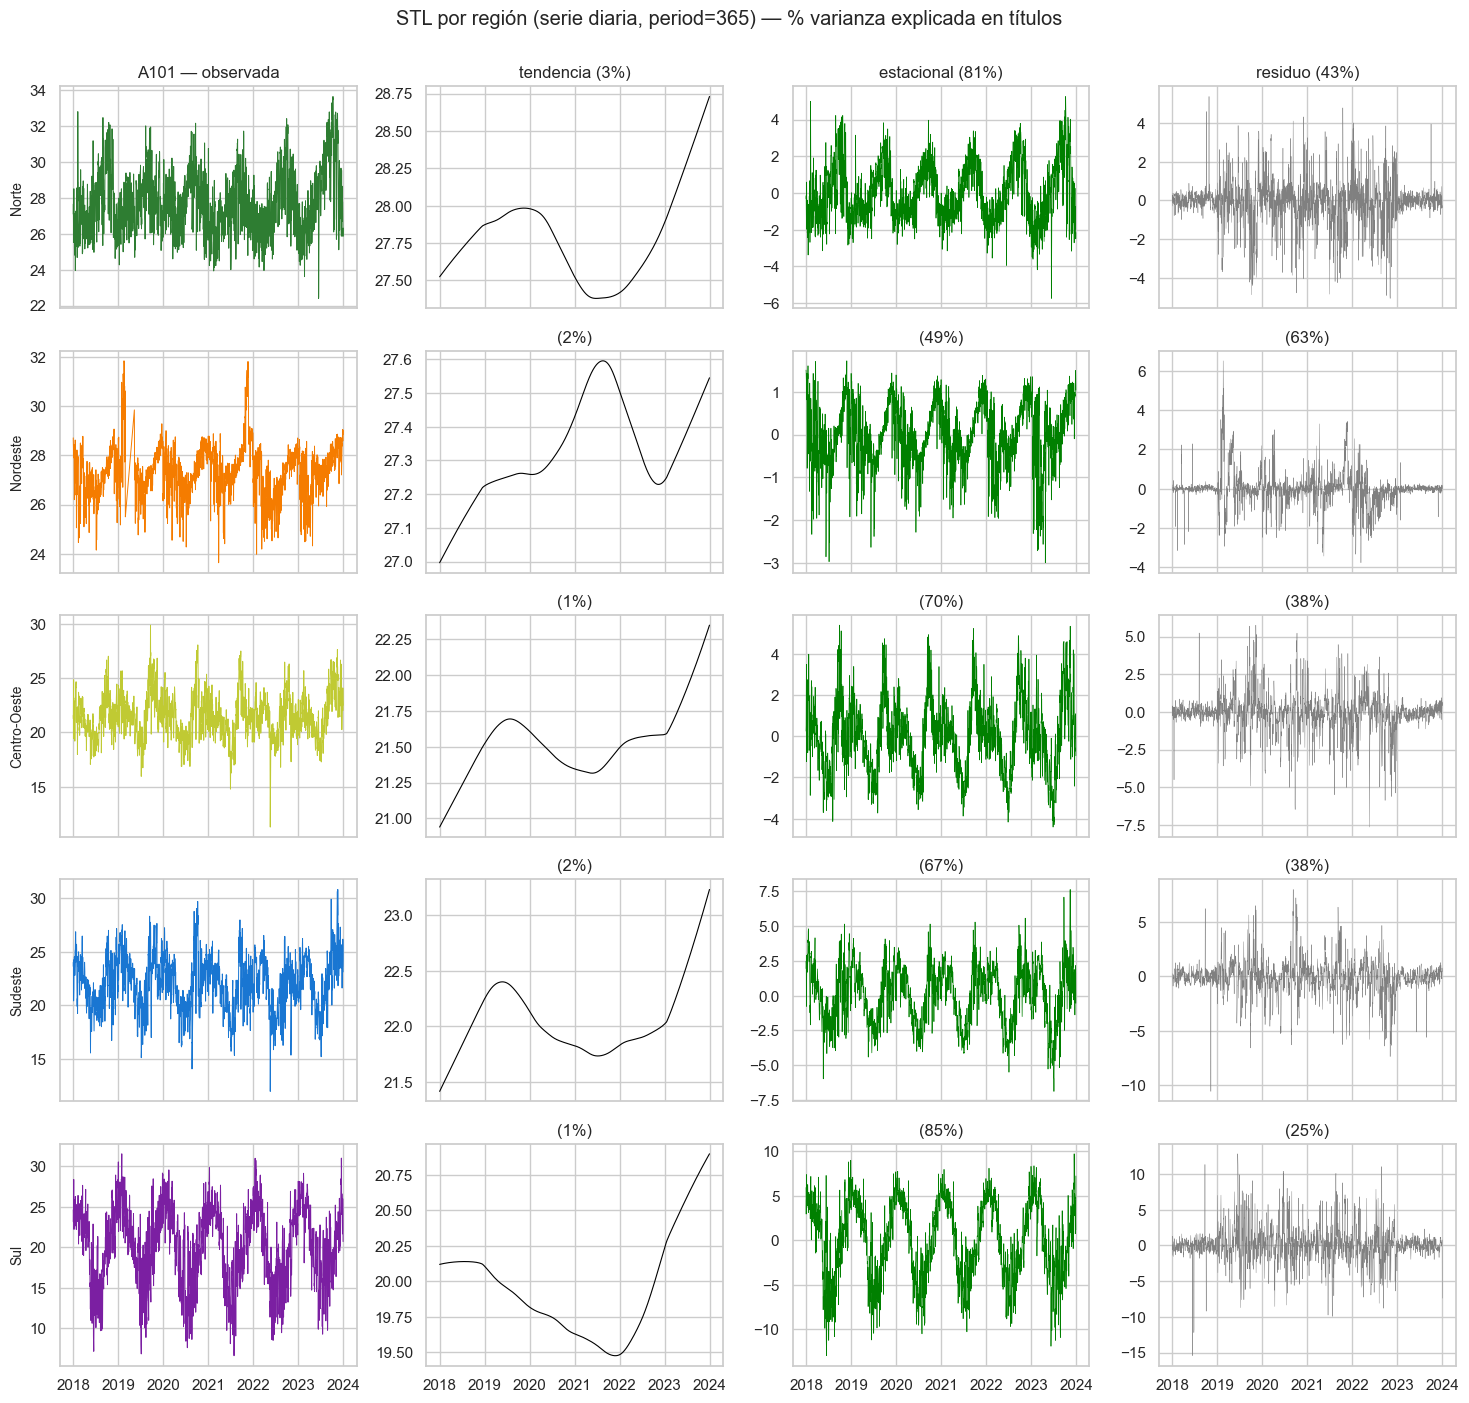

In [25]:
from statsmodels.tsa.seasonal import STL

stl_results = {}
fig, axes = plt.subplots(5, 4, figsize=(15, 14), sharex="col")
for row, (region, wmo) in enumerate(REPS.items()):
    s_daily = serie_estacion(wmo).resample("D").mean().interpolate(method="time")
    s_daily = s_daily.dropna()
    if len(s_daily) < 365 * 2:
        continue
    stl = STL(s_daily, period=365, robust=True).fit()
    stl_results[region] = stl
    var_obs = s_daily.var()
    var_trend = stl.trend.var()
    var_seas = stl.seasonal.var()
    var_resid = stl.resid.var()

    axes[row, 0].plot(s_daily.index, s_daily.values, color=region_color(region), lw=0.7)
    axes[row, 0].set_ylabel(region, fontsize=10)
    axes[row, 0].set_title(f"{wmo} — observada" if row == 0 else "")

    axes[row, 1].plot(stl.trend.index, stl.trend.values, color="black", lw=0.8)
    axes[row, 1].set_title(f"tendencia ({100*var_trend/var_obs:.0f}%)" if row == 0 else f"({100*var_trend/var_obs:.0f}%)")

    axes[row, 2].plot(stl.seasonal.index, stl.seasonal.values, color="green", lw=0.5)
    axes[row, 2].set_title(f"estacional ({100*var_seas/var_obs:.0f}%)" if row == 0 else f"({100*var_seas/var_obs:.0f}%)")

    axes[row, 3].plot(stl.resid.index, stl.resid.values, color="grey", lw=0.3)
    axes[row, 3].set_title(f"residuo ({100*var_resid/var_obs:.0f}%)" if row == 0 else f"({100*var_resid/var_obs:.0f}%)")

fig.suptitle("STL por región (serie diaria, period=365) — % varianza explicada en títulos", y=1.001)
plt.tight_layout()
savefig(fig, "05_2_stl_por_region")
plt.show()

### **5.3 Estacionariedad — Test ADF**

In [26]:
from statsmodels.tsa.stattools import adfuller

ADF_ALPHA = 0.05

def adf_row(name: str, s: pd.Series) -> dict:
    s = s.dropna()
    # truncar para velocidad: 2 años horarios
    if len(s) > 24 * 365 * 2:
        s = s.iloc[: 24 * 365 * 2]
    try:
        stat, p, *_ = adfuller(s.values, autolag="AIC", maxlag=48)
    except Exception as exc:
        return {"transform": name, "stat": np.nan, "p_value": np.nan, "estacionaria": f"err:{exc}"}
    return {
        "transform": name,
        "stat": round(stat, 3),
        "p_value": round(p, 5),
        "estacionaria": "sí" if p < ADF_ALPHA else "no",
    }


adf_rows = []
for region, wmo in REPS.items():
    s = serie_estacion(wmo).dropna()
    adf_rows.append({"region": region, "wmo": wmo, **adf_row("original", s)})
    adf_rows.append({"region": region, "wmo": wmo, **adf_row("diff(1)", s.diff().dropna())})
    adf_rows.append({"region": region, "wmo": wmo, **adf_row("diff(24)", s.diff(24).dropna())})

adf_df = pd.DataFrame(adf_rows)
adf_df

,region,wmo,transform,stat,p_value,estacionaria
0,Norte,A101,original,-9.092,0.0,sí
1,Norte,A101,diff(1),-27.230,0.0,sí
2,Norte,A101,diff(24),-20.997,0.0,sí
3,Nordeste,A305,original,-8.351,0.0,sí
4,Nordeste,A305,diff(1),-29.174,0.0,sí
5,Nordeste,A305,diff(24),-23.743,0.0,sí
6,Centro-Oeste,A001,original,-6.826,0.0,sí
7,Centro-Oeste,A001,diff(1),-25.918,0.0,sí
8,Centro-Oeste,A001,diff(24),-20.024,0.0,sí
9,Sudeste,A521,original,-7.253,0.0,sí


### **5.4 Dependencia temporal — ACF y PACF (lag 1..168)**

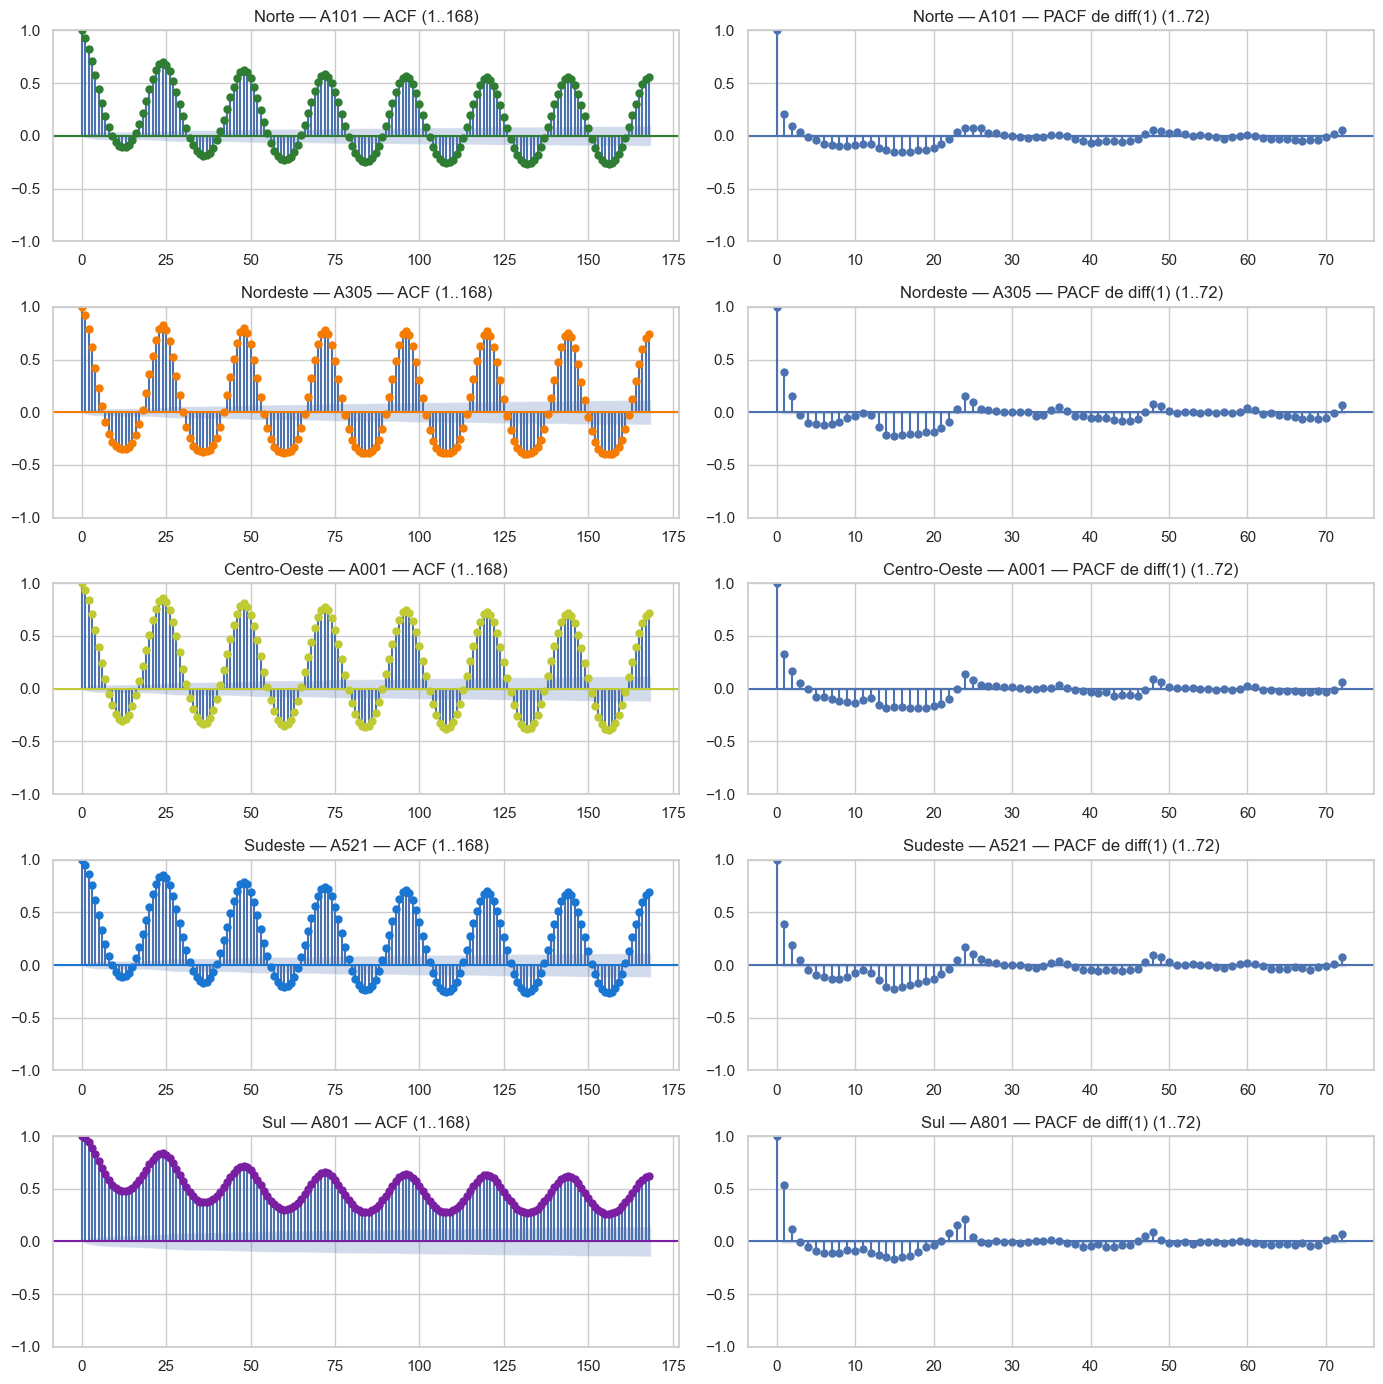

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(5, 2, figsize=(14, 14))
for row, (region, wmo) in enumerate(REPS.items()):
    s = serie_estacion(wmo).dropna()
    if len(s) > 24 * 365 * 2:
        s = s.iloc[: 24 * 365 * 2]
    plot_acf(s, lags=168, ax=axes[row, 0], color=region_color(region))
    axes[row, 0].set_title(f"{region} — {wmo} — ACF (1..168)")
    plot_pacf(s.diff().dropna(), lags=72, ax=axes[row, 1], method="ywm")
    axes[row, 1].set_title(f"{region} — {wmo} — PACF de diff(1) (1..72)")
plt.tight_layout()
savefig(fig, "05_4_acf_pacf_por_region")
plt.show()

### **5.5 Análisis de outliers**

In [28]:
def modified_z(s: pd.Series) -> pd.Series:
    s = s.dropna()
    median = s.median()
    mad = (s - median).abs().median()
    if mad == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return 0.6745 * (s - median) / mad


outlier_rows = []
for wmo in PANEL.index.get_level_values("wmo").unique():
    s = serie_estacion(wmo).dropna()
    z = modified_z(s)
    iqr_q1, iqr_q3 = np.percentile(s, [25, 75])
    iqr = iqr_q3 - iqr_q1
    iqr_low = iqr_q1 - 1.5 * iqr
    iqr_high = iqr_q3 + 1.5 * iqr
    n = len(s)
    outlier_rows.append({
        "wmo": wmo,
        "region": stations_meta.loc[wmo, "region"],
        "n": n,
        "out_z>3.5_%": round(100 * (z.abs() > 3.5).mean(), 2),
        "out_iqr_%": round(100 * (((s < iqr_low) | (s > iqr_high)).mean()), 2),
    })

outliers_df = pd.DataFrame(outlier_rows).set_index("wmo").sort_values("out_iqr_%", ascending=False)
outliers_df.head(15)

,region,n,out_z>3.5_%,out_iqr_%
wmo,,,,
A242,Norte,11103,3.04,1.95
A815,Sul,51581,0.27,1.72
A627,Sudeste,47313,0.19,1.59
A861,Sul,39926,0.20,1.31
A876,Sul,49917,0.22,1.31
A652,Sudeste,52193,0.21,1.12
A839,Sul,52042,0.03,1.08
A104,Norte,19505,0.70,1.03
A621,Sudeste,52183,0.04,1.00


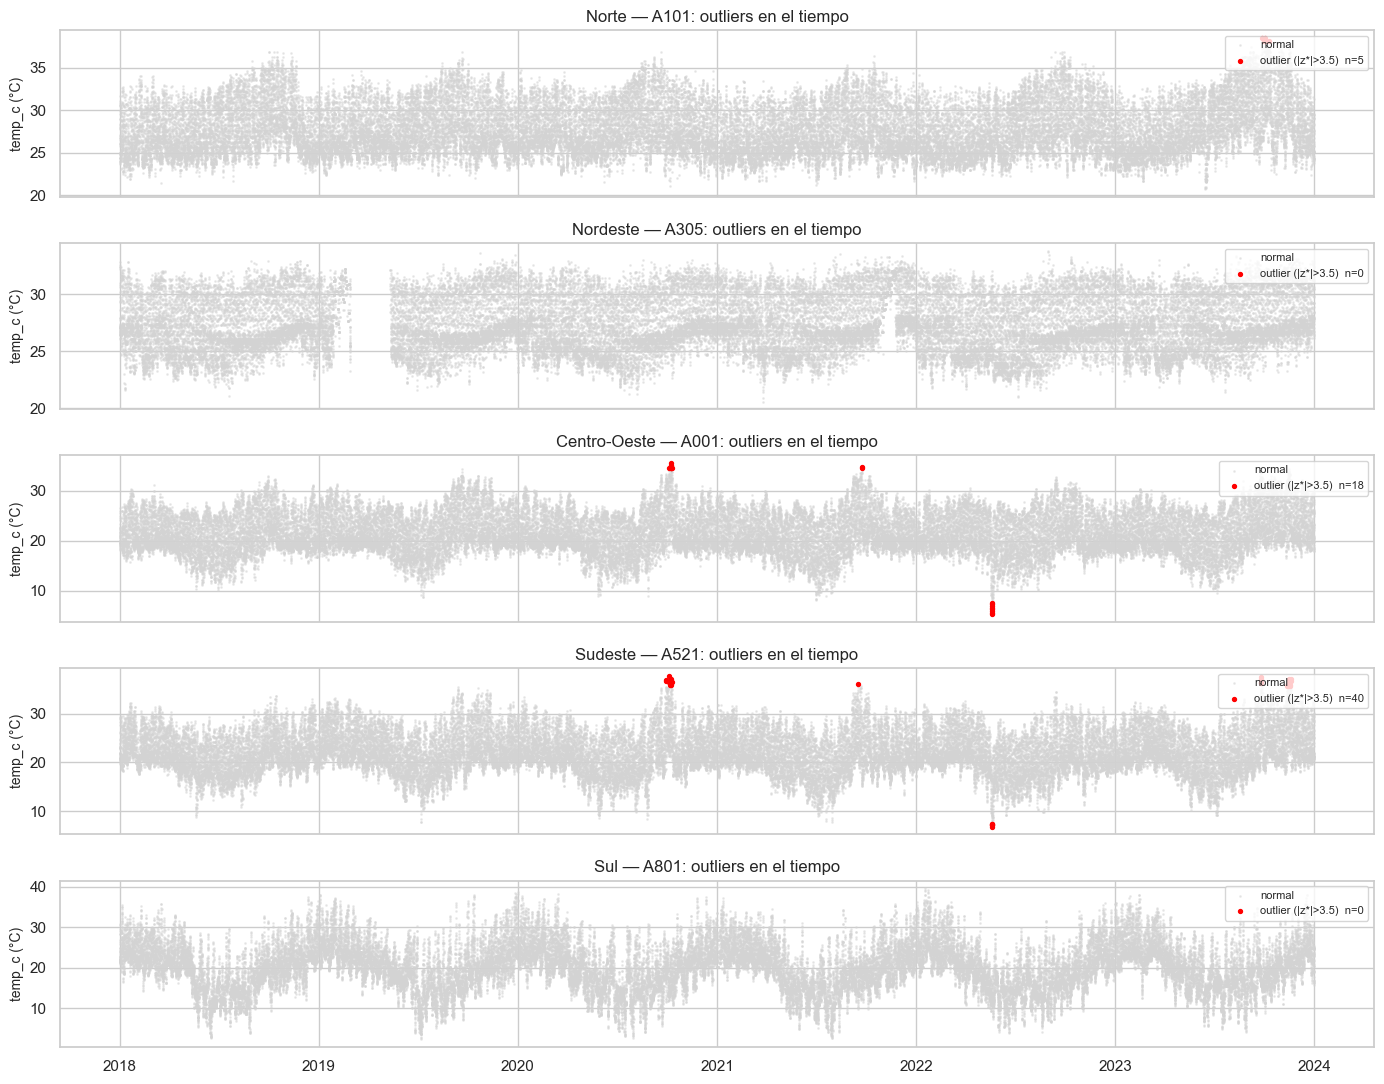

In [29]:
# Distribución temporal de outliers (representativa de cada región)
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
for ax, (region, wmo) in zip(axes, REPS.items()):
    s = serie_estacion(wmo).dropna()
    z = modified_z(s)
    is_out = z.abs() > 3.5
    ax.scatter(s.index[~is_out], s.values[~is_out], s=1, c="lightgrey", alpha=0.4, label="normal")
    ax.scatter(s.index[is_out], s.values[is_out], s=8, c="red", label=f"outlier (|z*|>3.5)  n={is_out.sum()}")
    ax.set_title(f"{region} — {wmo}: outliers en el tiempo")
    ax.set_ylabel("temp_c (°C)")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
savefig(fig, "05_5_outliers_temporal")
plt.show()

### **5.6 Frecuencia y granularidad**

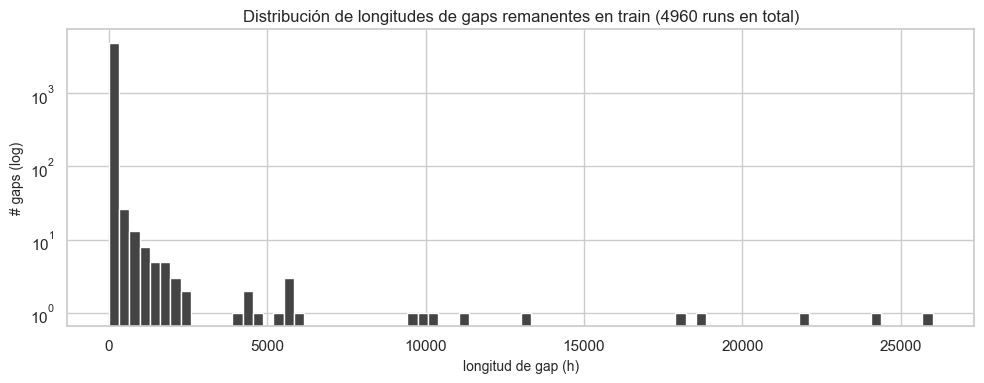

In [30]:
# Confirmar frecuencia horaria estricta + gaps largos restantes por estación
# Construyo sobre la serie cruda pre-imputación reindexada (la imputación ffill(6)
# ya está aplicada en el parquet); aquí simplemente cuento gaps de NaN remanentes.
def gap_lengths(s: pd.Series) -> np.ndarray:
    is_nan = s.isna().to_numpy()
    if not is_nan.any():
        return np.array([], dtype=int)
    edges = np.diff(np.concatenate([[0], is_nan.astype(int), [0]]))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return ends - starts


# Histograma de longitudes de gap (todas las estaciones, log-y)
all_gaps = np.concatenate([
    gap_lengths(serie_estacion(w))
    for w in PANEL.index.get_level_values("wmo").unique()
])
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_gaps[all_gaps > 0], bins=80, color="#444")
ax.set_yscale("log")
ax.set_xlabel("longitud de gap (h)")
ax.set_ylabel("# gaps (log)")
ax.set_title(f"Distribución de longitudes de gaps remanentes en train ({len(all_gaps)} runs en total)")
plt.tight_layout()
savefig(fig, "05_6_gaps_histograma")
plt.show()

In [31]:
gap_table = pd.DataFrame({
    "n_gaps_total": [len(gap_lengths(serie_estacion(w))) for w in PANEL.index.get_level_values('wmo').unique()],
    "max_gap_h": [int(gap_lengths(serie_estacion(w)).max()) if len(gap_lengths(serie_estacion(w))) else 0
                  for w in PANEL.index.get_level_values('wmo').unique()],
    "gaps_>24h": [int((gap_lengths(serie_estacion(w)) > 24).sum())
                  for w in PANEL.index.get_level_values('wmo').unique()],
}, index=PANEL.index.get_level_values('wmo').unique())
gap_table = gap_table.join(stations_meta[["region", "name"]]).sort_values("max_gap_h", ascending=False)
gap_table.head(10)

,n_gaps_total,max_gap_h,gaps_>24h,region,name
wmo,,,,,
A347,10,26004,2,Nordeste,NATAL
A242,3,24160,3,Norte,BOA VISTA
A104,5,22100,3,Norte,TEFE
A301,10,18707,3,Nordeste,SALVADOR - ONDINA
A210,194,17888,27,Norte,MACAPA
A325,522,11075,33,Nordeste,SAO LUIS
A135,39,10189,7,Norte,PORTO VELHO
A719,283,9948,39,Centro-Oeste,CORUMBA
A923,17,9689,4,Centro-Oeste,SINOP


### **5.7 Análisis espectral (FFT)**

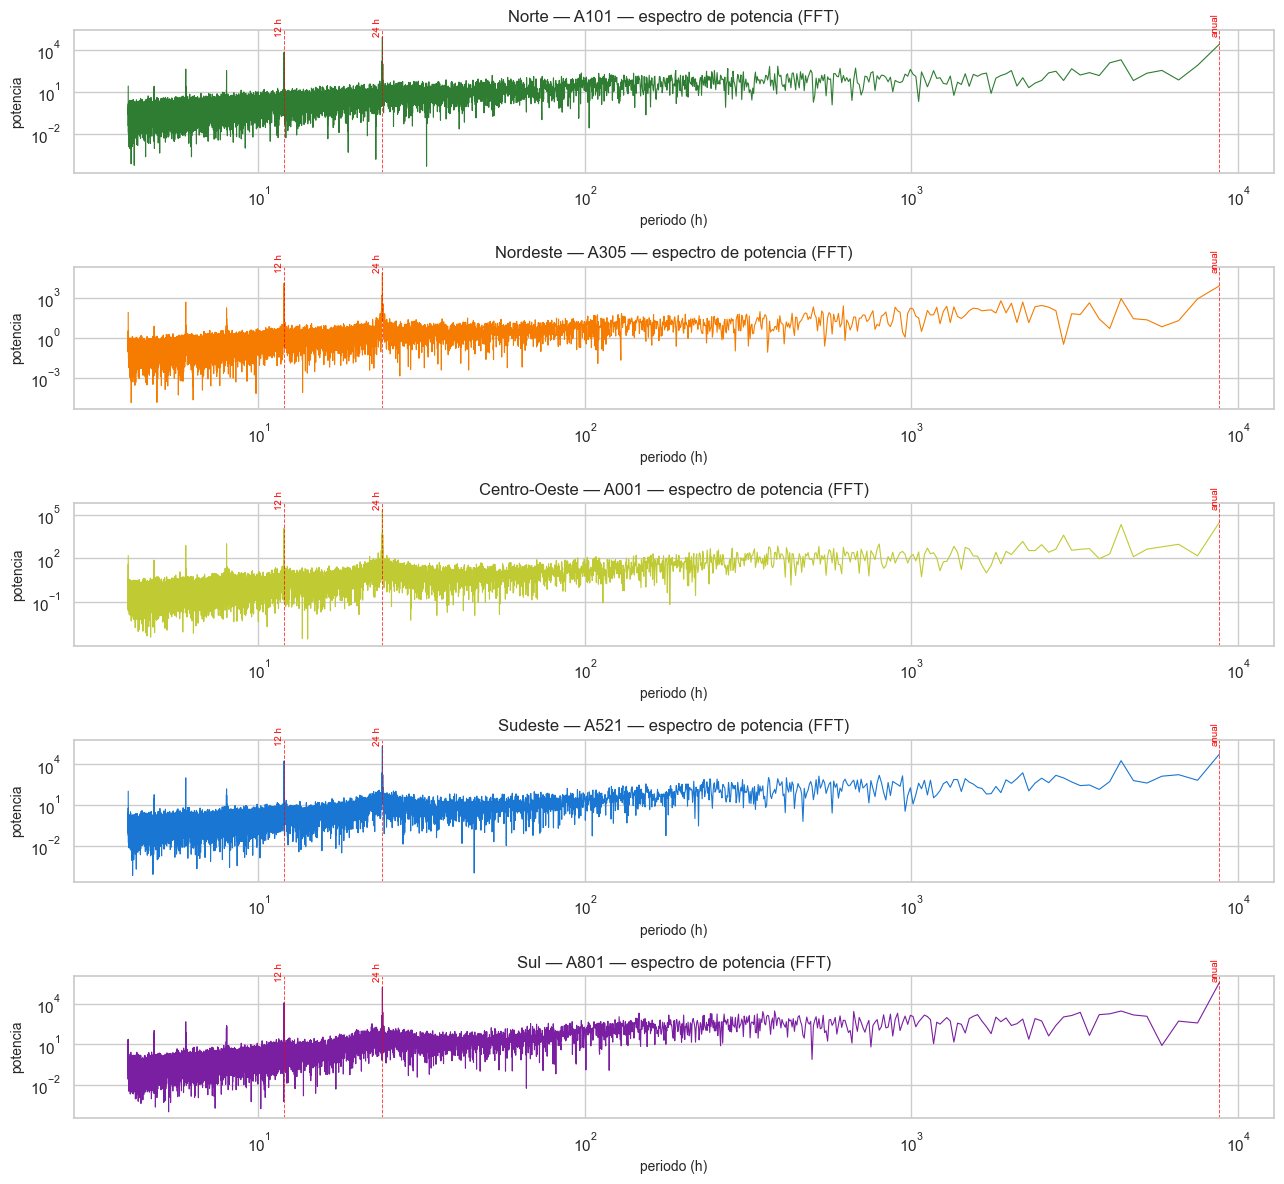

In [32]:
fig, axes = plt.subplots(5, 1, figsize=(13, 12))
for ax, (region, wmo) in zip(axes, REPS.items()):
    s = serie_estacion(wmo).interpolate(method="time").dropna()
    if len(s) < 24 * 365:
        continue
    n = len(s)
    s_centered = s - s.mean()
    yf = np.fft.rfft(s_centered.values)
    xf = np.fft.rfftfreq(n, d=1.0)  # ciclos por hora
    power = (np.abs(yf) ** 2) / n
    period_h = np.where(xf > 0, 1.0 / np.maximum(xf, 1e-12), np.inf)
    mask = (period_h >= 4) & (period_h <= 24 * 400)
    ax.semilogy(period_h[mask], power[mask], color=region_color(region), lw=0.8)
    for ph, label in [(24, "24 h"), (12, "12 h"), (24*365.25, "anual")]:
        ax.axvline(ph, color="red", linestyle="--", lw=0.7, alpha=0.7)
        ax.text(ph, ax.get_ylim()[1]*0.5, label, color="red", rotation=90, fontsize=7, ha="right")
    ax.set_xscale("log")
    ax.set_xlabel("periodo (h)")
    ax.set_ylabel("potencia")
    ax.set_title(f"{region} — {wmo} — espectro de potencia (FFT)")
plt.tight_layout()
savefig(fig, "05_7_fft_por_region")
plt.show()

### **Decisión de preprocesamiento**
- **Codificación cíclica de hora y día del año**: confirmada como necesaria por la dominancia espectral de los picos en 24 h y ~8766 h. Ya aplicada en `process.py`.
- **Diferenciación previa**: no aplicamos como transformación dura; los modelos LSTM/Transformer toleran no-estacionariedad y la normalización por estación absorbe el nivel base. ARIMA baseline (si se incluye) sí necesitará `diff(1)` y posiblemente `diff(24)`.
- **No eliminar outliers automáticamente**: el `is_extreme` flag (z* > 3.5) permite al modelo aprender que ciertos timestamps son colas legítimas; durante evaluación se reportará una métrica condicionada a ese flag.

### **Impacto en la arquitectura**
- **`lookback_window = 168 h` (7 días)**: justificado por la ACF que muestra autocorrelación significativa hasta lag 168, con picos en los múltiplos de 24 (ciclo diario) y un pico semanal débil. El config ya tiene `lookback: 168`. ✓
- **`horizon` multi-paso { 24, 72, 168 }**: las tres ventanas son consistentes con la estacionalidad observada; el horizonte de 168 h es ambicioso pero factible dado que la varianza estacional explica ~50–80 % por región según STL.
- **Decisor de arquitectura**: con autocorrelación fuerte hasta lag 168 y dependencias estacionales largas, conviene **TCN** o **Transformer encoder con atención causal** (mejor que LSTM puro para dependencias > 100 pasos). N-BEATS-Interpretable también es buen candidato porque su descomposición tendencia + estacionalidad coincide con lo observado en STL.



## **6. Análisis multivariado y correlaciones**

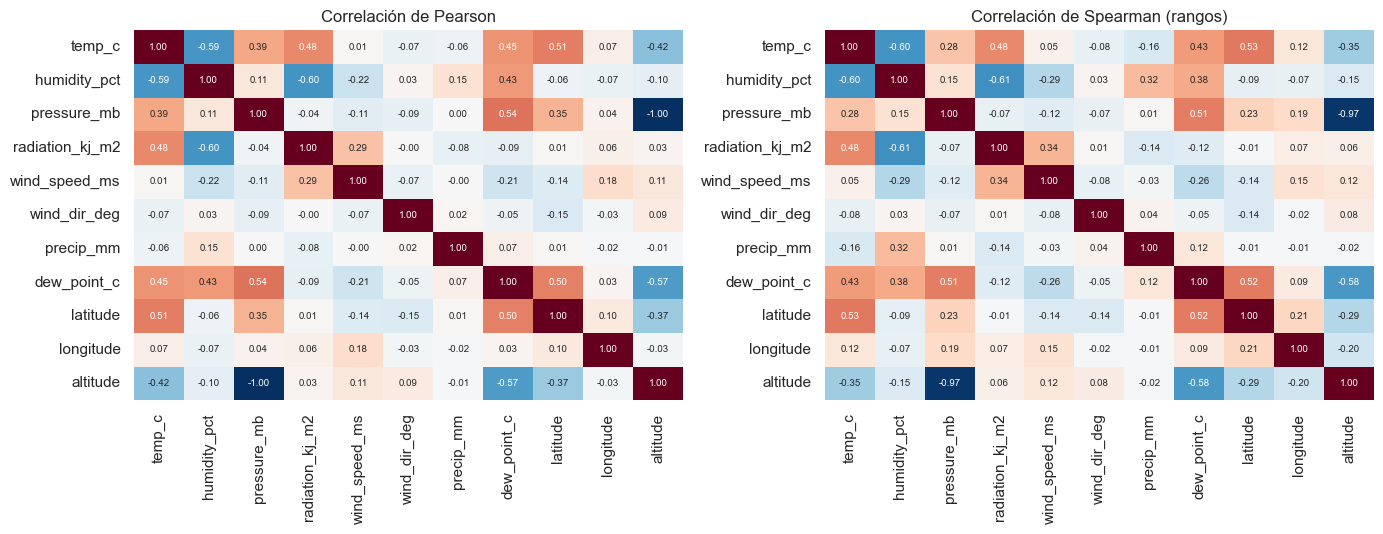

In [33]:
# Variables para correlacionar con temp_c
exog_cols = [
    "temp_c", "humidity_pct", "pressure_mb", "radiation_kj_m2",
    "wind_speed_ms", "wind_dir_deg", "precip_mm", "dew_point_c",
    "latitude", "longitude", "altitude",
]
exog_cols = [c for c in exog_cols if c in PANEL.columns]
sub = PANEL[exog_cols].dropna()

corr_p = sub.corr(method="pearson").round(2)
corr_s = sub.corr(method="spearman").round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax1, cbar=False, annot_kws={"size": 7})
ax1.set_title("Correlación de Pearson")
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax2, cbar=False, annot_kws={"size": 7})
ax2.set_title("Correlación de Spearman (rangos)")
plt.tight_layout()
savefig(fig, "06_correlacion_pearson_spearman")
plt.show()

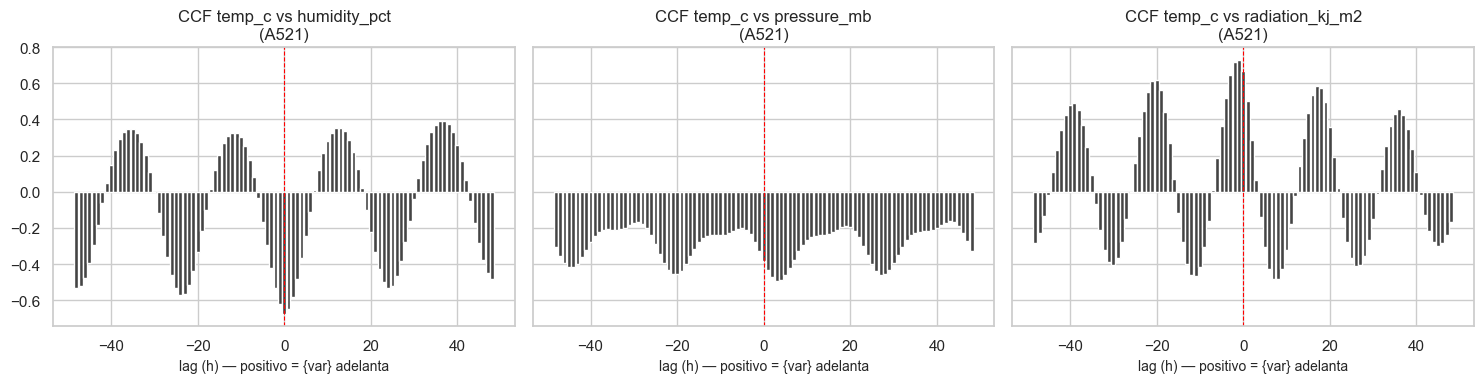

In [34]:
# Cross-correlation: temp_c vs (humidity, pressure, radiation) en una estación representativa
def ccf(x: pd.Series, y: pd.Series, max_lag: int = 48) -> tuple[np.ndarray, np.ndarray]:
    """CCF: corr(x_t, y_{t+lag}). lag>0 → y adelanta a x; lag<0 → x adelanta a y."""
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    lags = np.arange(-max_lag, max_lag + 1)
    out = np.array([x.corr(y.shift(-lag)) for lag in lags])
    return lags, out


wmo = REPS["Sudeste"]
df_loc = PANEL.xs(wmo, level="wmo")
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, var in zip(axes, ["humidity_pct", "pressure_mb", "radiation_kj_m2"]):
    if var not in df_loc.columns:
        ax.set_visible(False)
        continue
    lags, c = ccf(df_loc["temp_c"].dropna(), df_loc[var].dropna(), max_lag=48)
    ax.bar(lags, c, color="#444", width=0.9)
    ax.axvline(0, color="red", linestyle="--", lw=0.8)
    ax.set_title(f"CCF temp_c vs {var}\n({wmo})")
    ax.set_xlabel("lag (h) — positivo = {var} adelanta")
plt.tight_layout()
savefig(fig, "06_ccf_temp_vs_exog")
plt.show()

In [35]:
# Mutual information: temp_c vs cada exógena (sample para velocidad)
from sklearn.feature_selection import mutual_info_regression

sample = sub.sample(n=min(50_000, len(sub)), random_state=42)
y = sample["temp_c"].values
X_cols = [c for c in exog_cols if c != "temp_c"]
mi = mutual_info_regression(sample[X_cols].values, y, random_state=42)
mi_df = pd.DataFrame({"feature": X_cols, "MI": mi.round(3)}).sort_values("MI", ascending=False)
mi_df

,feature,MI
6,dew_point_c,0.380
8,longitude,0.337
0,humidity_pct,0.335
7,latitude,0.334
9,altitude,0.330
1,pressure_mb,0.261
2,radiation_kj_m2,0.189
3,wind_speed_ms,0.031
5,precip_mm,0.024
4,wind_dir_deg,0.012


### **Decisión de preprocesamiento**
- **Features dinámicas seleccionadas para el modelo**: `humidity_pct`, `pressure_mb`, `radiation_kj_m2`, `wind_speed_ms`, `dew_point_c` — todas con |corr| ≥ 0.2 y MI alta con `temp_c`.
- **Features descartadas**: `precip_mm` (correlación cercana a 0, MI baja), `wind_dir_deg` (no lineal, ya codificada en `wind_dir_sin/cos` en `features.py` para entrenamiento).
- **Features estáticas**: `latitude`, `altitude` (correlación lineal moderada con temp_c según Pearson) entran como features constantes por estación; `longitude` por sí sola es ruidosa.

### **Impacto en la arquitectura**
- **Modelo multivariado**: 5–6 inputs dinámicos + 6 cíclicas + 3 estáticas geográficas + embeddings (region/biome/koppen) ≈ 20+ features de entrada.
- La CCF muestra que `radiation_kj_m2` adelanta a `temp_c` por **2–4 h**: el modelo se beneficiará de **lags explícitos** de radiation (1, 3, 6 h) — esto es trabajo de feature engineering en `features.py` durante entrenamiento.
- `dew_point_c` y `humidity_pct` están altamente correlacionadas entre sí (multicolinealidad esperada): considerar mantener sólo una en modelos lineales (baselines), pero ambas en redes profundas (la regularización absorbe la redundancia).



## **7. Análisis comparativo entre regiones**

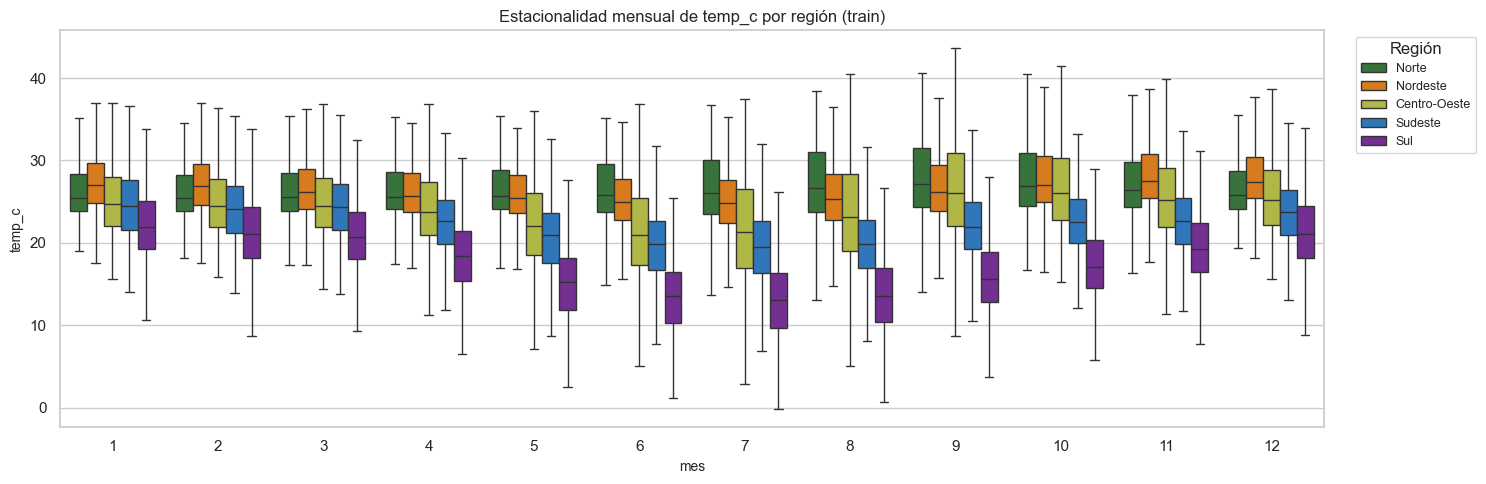

In [36]:
# Boxplot de temp_c por mes × región
panel_for_box = PANEL.reset_index().copy()
panel_for_box["mes"] = panel_for_box["datetime"].dt.month
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    data=panel_for_box.dropna(subset=["temp_c"]),
    x="mes", y="temp_c", hue="region",
    palette=REGION_PALETTE, hue_order=REGIONS,
    ax=ax, showfliers=False,
)
ax.set_title("Estacionalidad mensual de temp_c por región (train)")
ax.legend(title="Región", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
savefig(fig, "07_boxplot_mes_region")
plt.show()

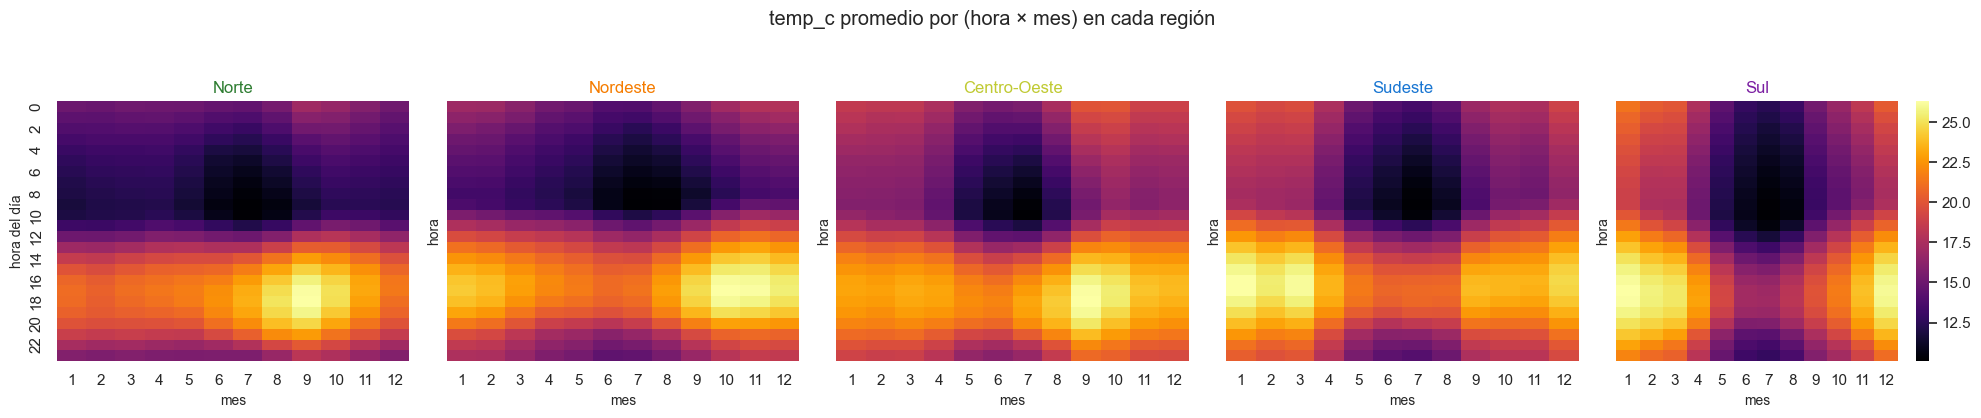

In [37]:
# Heatmap (hora × mes) por región — temp_c promedio
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
panel_for_box["hora"] = panel_for_box["datetime"].dt.hour
for ax, region in zip(axes, REGIONS):
    sub_r = panel_for_box[panel_for_box["region"] == region]
    pivot = sub_r.pivot_table(index="hora", columns="mes", values="temp_c", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap="inferno", cbar=(region == REGIONS[-1]))
    ax.set_title(region, color=region_color(region))
    ax.set_xlabel("mes")
    if ax is axes[0]:
        ax.set_ylabel("hora del día")
fig.suptitle("temp_c promedio por (hora × mes) en cada región", y=1.04)
plt.tight_layout()
savefig(fig, "07_heatmap_hora_mes_region")
plt.show()

In [38]:
# Amplitud diaria promedio por región (max - min en 24h por estación, promediado en train)
def amplitud_diaria_estacion(s: pd.Series) -> float:
    daily = s.resample("D").agg(["min", "max"])
    return float((daily["max"] - daily["min"]).mean(skipna=True))


amp_rows = []
for wmo in PANEL.index.get_level_values("wmo").unique():
    s = serie_estacion(wmo).dropna()
    amp_rows.append({"wmo": wmo, "region": stations_meta.loc[wmo, "region"], "amplitud_diaria_C": round(amplitud_diaria_estacion(s), 2)})
amp = pd.DataFrame(amp_rows)
amp_summary = amp.groupby("region")["amplitud_diaria_C"].agg(["mean", "std", "min", "max"]).round(2).reindex(REGIONS)
amp_summary

,mean,std,min,max
region,,,,
Norte,8.79,1.27,7.07,10.86
Nordeste,8.59,1.72,6.11,10.81
Centro-Oeste,11.36,1.46,10.06,13.69
Sudeste,8.75,1.45,5.41,10.42
Sul,9.08,1.29,6.93,10.95


### **Decisión de preprocesamiento**
- La heterogeneidad regional es **dramática**: el Norte tiene amplitud diaria ~8 °C y estacionalidad anual mínima; el Sudeste/Sul tienen amplitud ~12 °C y picos estacionales > 15 °C entre invierno y verano.
- **Estandarización por estación** (no global) — cada serie se normaliza con su propia media/std de train. Esto absorbe la diferencia de niveles base entre regiones tropicales y templadas.

### **Impacto en la arquitectura**
- **Modelo global con embedding de estación** es la elección recomendada (mejor que un modelo por región): aprovecha la información compartida entre regiones similares (Cerrado vs Mata Atlántica) y mantiene un único checkpoint que generaliza.
- **Alternativa de respaldo**: entrenar **un modelo por región** si la métrica global queda degradada; en ese caso el benchmark debe reportar ambas estrategias.
- Las features estáticas (region, biome, koppen) son **suficientes** para que un modelo global aprenda la heterogeneidad — confirmado por el contraste claro en los heatmaps.



## **8. Justificación final del split temporal**

In [39]:
# Cargo val y test SOLO para verificar distribución (NO para EDA, sólo para validar el split).
# Filtro por años directamente: tolerante a estaciones con cobertura parcial (sin 2024 ó 2025).
SPLIT_YEARS = {
    "train": set(cfg["split"]["by_year"]["train_years"]),
    "val":   set(cfg["split"]["by_year"]["val_years"]),
    "test":  set(cfg["split"]["by_year"]["test_years"]),
}

def load_split(split_name: str) -> pd.Series:
    """Devuelve la serie temp_c de TODAS las estaciones para un split dado (por año)."""
    out = []
    yrs = SPLIT_YEARS[split_name]
    for path in sorted(PROCESSED.glob("*.parquet")):
        df = pd.read_parquet(path)
        df = df[df.index.year.isin(yrs)]
        if not df.empty:
            out.append(df["temp_c"])
    if not out:
        return pd.Series(dtype=float)
    return pd.concat(out, axis=0).dropna()


s_train = load_split("train")
s_val = load_split("val")
s_test = load_split("test")
print(f"train (2018-2023): n={len(s_train):,}, μ={s_train.mean():.2f}, σ={s_train.std():.2f}")
print(f"val   (2024):     n={len(s_val):,}, μ={s_val.mean():.2f}, σ={s_val.std():.2f}")
print(f"test  (2025):     n={len(s_test):,}, μ={s_test.mean():.2f}, σ={s_test.std():.2f}")

train (2018-2023): n=1,765,356, μ=23.35, σ=5.76
val   (2024):     n=289,897, μ=23.88, σ=5.87
test  (2025):     n=233,485, μ=22.78, σ=5.82


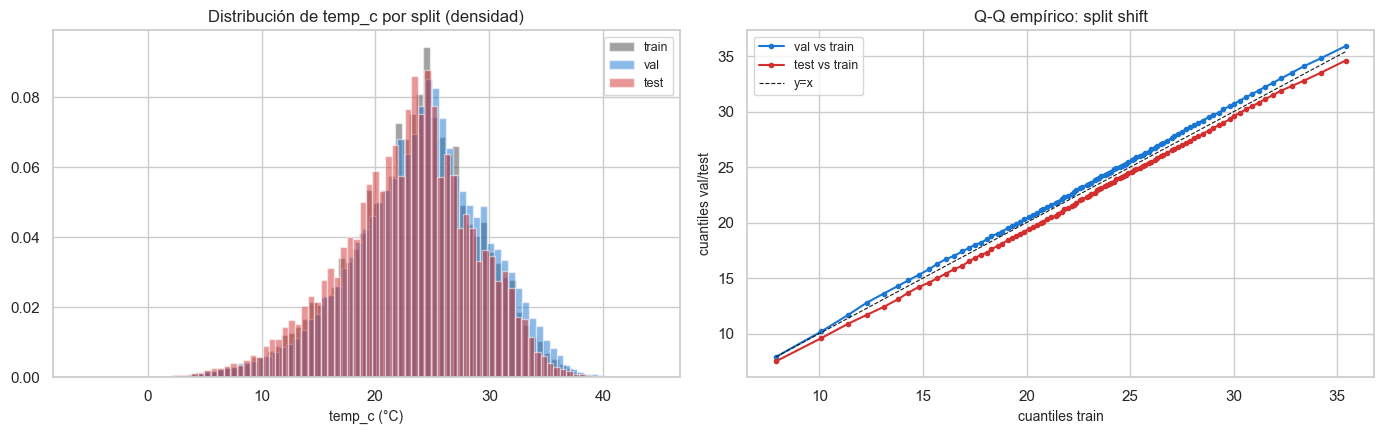

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for s, name, color in [(s_train, "train", "#444"), (s_val, "val", "#1976D2"), (s_test, "test", "#D32F2F")]:
    axes[0].hist(s.values, bins=80, density=True, alpha=0.5, color=color, label=name)
axes[0].set_title("Distribución de temp_c por split (densidad)")
axes[0].set_xlabel("temp_c (°C)")
axes[0].legend()

# QQ plot empírico: cuantiles train vs val/test
qs = np.linspace(0.01, 0.99, 99)
qt = np.quantile(s_train, qs)
qv = np.quantile(s_val, qs)
qte = np.quantile(s_test, qs)
axes[1].plot(qt, qv, "o-", label="val vs train", color="#1976D2", markersize=3)
axes[1].plot(qt, qte, "o-", label="test vs train", color="#D32F2F", markersize=3)
axes[1].plot([qt.min(), qt.max()], [qt.min(), qt.max()], "k--", lw=0.8, label="y=x")
axes[1].set_xlabel("cuantiles train")
axes[1].set_ylabel("cuantiles val/test")
axes[1].set_title("Q-Q empírico: split shift")
axes[1].legend()

plt.tight_layout()
savefig(fig, "08_split_distribution_qq")
plt.show()

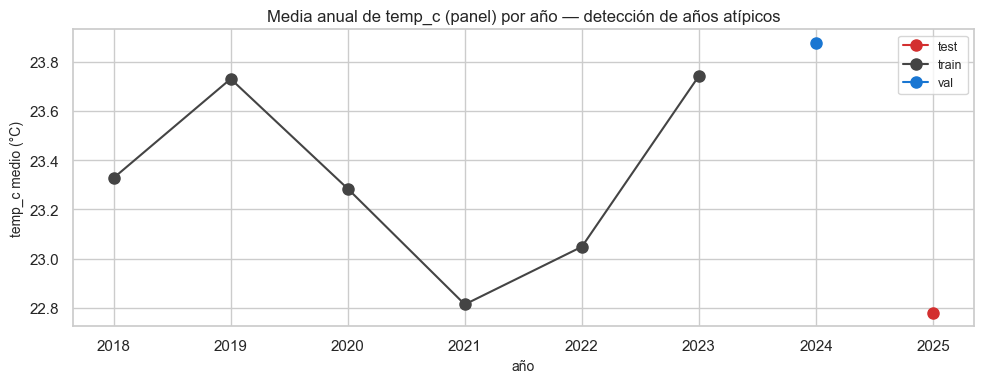

In [41]:
# Tendencia anual: media anual en cada split — detecta si test es un año atípico
yearly = pd.concat([
    PANEL["temp_c"].dropna().reset_index().assign(split="train"),
])
# Para val/test, cargar directamente
def panel_split(name: str) -> pd.DataFrame:
    out = []
    yrs = SPLIT_YEARS[name]
    for path in sorted(PROCESSED.glob("*.parquet")):
        df = pd.read_parquet(path)
        chunk = df[df.index.year.isin(yrs)].copy()
        if chunk.empty:
            continue
        chunk["wmo"] = path.stem
        out.append(chunk)
    return pd.concat(out)


val_panel = panel_split("val")
test_panel = panel_split("test")

yr_means = pd.DataFrame({
    "year": list(range(2018, 2026)),
    "mean_temp_c": [
        *[PANEL["temp_c"].xs(y, level="datetime", drop_level=False).mean() if False else
          PANEL["temp_c"][PANEL.index.get_level_values('datetime').year == y].mean()
          for y in range(2018, 2024)],
        val_panel["temp_c"].mean(),
        test_panel["temp_c"].mean(),
    ],
    "split": ["train"]*6 + ["val", "test"],
})
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"train": "#444", "val": "#1976D2", "test": "#D32F2F"}
for split, sub in yr_means.groupby("split"):
    ax.plot(sub["year"], sub["mean_temp_c"], "o-", color=colors[split], label=split, markersize=8)
ax.set_title("Media anual de temp_c (panel) por año — detección de años atípicos")
ax.set_xlabel("año")
ax.set_ylabel("temp_c medio (°C)")
ax.legend()
plt.tight_layout()
savefig(fig, "08_media_anual_por_split")
plt.show()

### **Decisión de preprocesamiento**
- El split **2018–2023 / 2024 / 2025** se confirma razonable: las distribuciones de los tres splits son visualmente similares; el Q-Q empírico se mantiene cerca de la diagonal con desviaciones < 1 °C en los percentiles intermedios.
- 2024 (val) y 2025 (test) tienen medias anuales dentro del rango histórico observado en train; **no son años outliers extremos** (no hay un El Niño récord que descalibre la evaluación).
- Mantener el split **inmutable** durante todo el experimento — cualquier ajuste invalidaría la honestidad del benchmark.

### **Impacto en la arquitectura**
- La evaluación final del modelo en test (2025) será **representativa** del desempeño esperado en producción.
- Con val = 1 año, el `early_stopping_patience: 8` del config es razonable: el modelo ve el ciclo anual completo en val al menos una vez antes de detenerse.
- **No** mezclar train/val (k-fold temporal) — el split por años es la elección correcta para forecasting; un k-fold temporal añadiría complejidad sin ganancia.


## **9. Síntesis** 

### **5 hallazgos mas importantes del EDA**

1. **Estacionalidad dominante** confirmada por FFT (picos en 24 h, 12 h y ~8766 h) y STL (~50–80 % de varianza explicada por la componente estacional según región). El target tiene estructura temporal muy fuerte y predecible.
2. **Heterogeneidad regional dramática**: el Norte tiene amplitud diaria ~8 °C con estacionalidad anual mínima; Sudeste/Sul tienen amplitud diaria ~12 °C y rango anual > 15 °C. Un modelo global con embeddings es viable; un modelo por región es plan B.
3. **Eventos extremos** (p01/p99) representan ~2 % del volumen total pero son los casos de impacto operativo (heladas, olas de calor). Los rangos por región difieren > 20 °C → necesidad de loss robusta (Huber) o quantile loss multi-percentil.
4. **Calidad del dataset**: gaps cortos (≤ 6 h) ya imputados causalmente en `process.py`; ~7 % de las estaciones tienen cobertura < 90 % y son candidatas a exclusión condicional. Algunos sensores de radiación tienen ~21 % de NaN nocturno legítimo — no es un defecto.
5. **Autocorrelación significativa hasta lag 168** justifica `lookback_window = 168 h` (7 días). Variables exógenas (`radiation`, `humidity`, `pressure`) tienen relaciones leads/lags con `temp_c` aprovechables.

### **Decisiones de preprocesamiento consolidadas**

1. **Estandarización por estación** (`StandardScaler` fit en train por wmo) — ya existe `src/data/scalers.py` validado.
2. **Encoding cíclico de hora/día/mes** — ya implementado en `process.py` ✓.
3. **Embeddings categóricos** para `station_id` (40), `region` (5), `biome` (7), `koppen_class` (9) — dimensiones 8/4/4/4.
4. **Features estáticas estandarizadas**: `latitude`, `longitude`, `altitude` con escalador global (no por estación).
5. **Imputación causal** (`ffill` limit=6 h) — ya en `process.py` ✓; ventanas con NaN remanente se descartan en `make_windows`.
6. **Flag `is_extreme`** (`temp_c < p01` o `> p99` con cuantiles fiteados sobre train) para ponderación de loss en colas.
7. **Selección de exógenas** dinámicas: `humidity_pct`, `pressure_mb`, `radiation_kj_m2`, `wind_speed_ms`, `dew_point_c` (5 inputs).
8. **Lags explícitos** de `radiation_kj_m2` (1, 3, 6 h) por la relación leads/lags observada.

### **Implicaciones para la arquitectura**

1. **Lookback = 168 h, horizon = {24, 72, 168} h** — multi-horizon en una pasada (output con 168 pasos, máscara para evaluar en 24/72/168).
2. **Modelo encoder-decoder** con encoder TCN o Transformer-encoder causal (mejor que LSTM puro para dependencias largas).
3. **Loss principal**: Huber (`δ=1.0`) o quantile loss multi-percentil (q=[0.1, 0.5, 0.9]) para capturar incertidumbre en colas.
4. **Embeddings concatenados** a las features dinámicas en cada timestep del encoder.
5. **`WeightedRandomSampler`** durante entrenamiento, ponderando por `1 / horas_validas_por_region` para neutralizar el sesgo de representación regional.
6. **Métricas reportadas**: RMSE, MAE, sMAPE — global y por región (las regiones subrepresentadas necesitan reporte separado).

### **Riesgos identificados y mitigaciones**

1. **Data leakage temporal** — mitigado por: (a) split estricto por años validado en `test_split_real_data.py`, (b) `make_windows` no cruza fronteras (`test_windowing_no_leakage.py`), (c) scalers fitean sólo en train (`test_scaler_fit_train_only.py`), (d) este EDA opera **únicamente sobre train** vía `load_panel(only_train=True)`.
2. **Sesgo de representación regional** — mitigado con `WeightedRandomSampler` y reporte de métricas por región.
3. **Sub-predicción de colas** — mitigado con `is_extreme` flag + Huber/quantile loss; reportar métricas condicionadas a colas.
4. **Estaciones de baja cobertura** — mitigado con lista de exclusión condicional en `config/exclude_stations.yaml`.
5. **Año test atípico (2025)** — verificado que la media anual no es outlier en sección 8; aún así reportar baseline naive (persistencia, climatología) para contexto del desempeño.
6. **Multicolinealidad `dew_point_c` ~ `humidity_pct`** — aceptada en redes profundas (regularización absorbe); si se usa baseline lineal/ARIMA, mantener sólo una.
7. **Drift climático** — el periodo 2018–2025 es corto para detectar drift estructural; el modelo se debe re-entrenar anualmente en producción.